In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

# Run DGE

In [9]:
path_resp = dict(zip(['01','02','03','04','05','06'],['PR','CR','CR','CR','CR','PR']))

In [3]:
import memento

In [4]:
adata_raw_noHC_no_NA_outcome_high_conf = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf.h5ad")

In [10]:
adata_raw_noHC_no_NA_outcome_high_conf.obs['patient'].map(path_resp)

AAACCTGAGAGGTTAT-1_05_pre     CR
AAACCTGAGCTAGTGG-1_04_post    CR
AAACCTGAGGAATTAC-1_05_pre     CR
AAACCTGAGGCGCTCT-1-4          CR
AAACCTGCAAACCCAT-1_04_post    CR
                              ..
TTTGTCATCAAGATCC-1_01_pre     PR
TTTGTCATCATGTCTT-1_02_post    CR
TTTGTCATCGAGAGCA-1_01_pre     PR
TTTGTCATCGCACTCT-1_02_post    CR
TTTGTCATCTGTTGAG-1_05_post    CR
Name: patient, Length: 8934, dtype: object

In [11]:
adata_raw_noHC_no_NA_outcome_high_conf.obs['path_resp'] = adata_raw_noHC_no_NA_outcome_high_conf.obs['patient'].map(path_resp)

In [12]:
adata_raw_noHC_no_NA_outcome_high_conf

AnnData object with n_obs × n_vars = 8934 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp'
    obsm: 'X_umap'
    layers: 'counts'

In [13]:
Apexigen_emb_no_HC = sc.read_h5ad("Apexigen_emb_no_HC.h5ad")

In [16]:
Apexigen_emb_no_HC.obs['path_resp'] = Apexigen_emb_no_HC.obs['patient'].map(path_resp)

In [17]:
Apexigen_emb_no_HC.obs['path_resp'].value_counts()

path_resp
CR    12377
PR     1687
Name: count, dtype: int64

In [15]:
Apexigen_emb_no_HC.obs['response'].value_counts()

response
pathCR      12377
nopathCR     1687
Name: count, dtype: int64

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


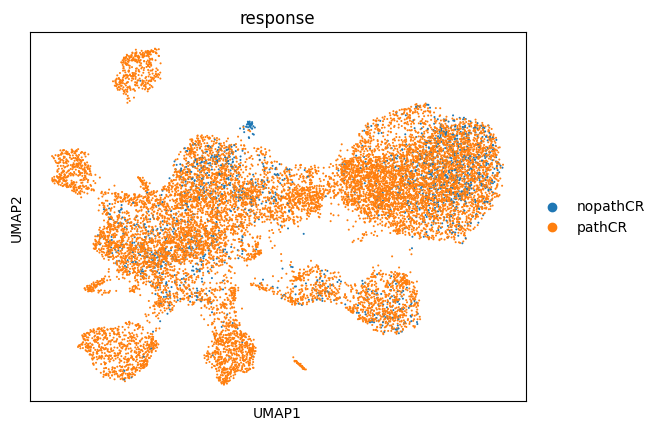

In [14]:
sc.pl.umap(
    Apexigen_emb_no_HC,
    color="response"
)

In [27]:
import math
from statsmodels.stats.multitest import multipletests

# Compare Pre vs. Post for predicted TAA for responders

In [18]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR = adata_raw_noHC_no_NA_outcome_high_conf[adata_raw_noHC_no_NA_outcome_high_conf.obs['response'] == "pathCR"]
adata_raw_noHC_no_NA_outcome_high_conf_pathCR

View of AnnData object with n_obs × n_vars = 7009 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp'
    obsm: 'X_umap'
    layers: 'counts'

In [19]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR.obs['timepoint'].value_counts()

timepoint
post_CD40    3336
pre_CD40     3277
surgery       273
follow_up     123
Name: count, dtype: int64

In [20]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post = adata_raw_noHC_no_NA_outcome_high_conf_pathCR[adata_raw_noHC_no_NA_outcome_high_conf_pathCR.obs['timepoint'].str.contains("pre|post")]
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post

View of AnnData object with n_obs × n_vars = 6613 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp'
    obsm: 'X_umap'
    layers: 'counts'

In [21]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['timepoint_ref_pre'] = (adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['timepoint'] != "pre_CD40") + 0

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_43569/1568032250.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['timepoint_ref_pre'] = (adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['timepoint'] != "pre_CD40") + 0


In [24]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['timepoint_ref_pre']

AAACCTGAGAGGTTAT-1_05_pre     0
AAACCTGAGCTAGTGG-1_04_post    1
AAACCTGAGGAATTAC-1_05_pre     0
AAACCTGAGGCGCTCT-1-4          1
AAACCTGCAAACCCAT-1_04_post    1
                             ..
TTTGTCACAGGTGGAT-1_03_pre     0
TTTGTCACATGAACCT-1_02_post    1
TTTGTCATCATGTCTT-1_02_post    1
TTTGTCATCGCACTCT-1_02_post    1
TTTGTCATCTGTTGAG-1_05_post    1
Name: timepoint_ref_pre, Length: 6613, dtype: int64

In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.write("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.h5ad")

In [23]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.h5ad")

In [25]:
result_1d_pre_post_TAA = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post, 
    capture_rate=0.03, 
    treatment_col='timepoint_ref_pre', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    7.4s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:   23.1s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:   56.2s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:  1.6min
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:  2.5min
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:  3.5min
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:  5.0min
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:  6.7min
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:  8.8min
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed: 10.8min
[Parallel(n_job

In [127]:
result_1d_CR_PD_TAA_pre_post_ref_TAA_CR_no_path = pd.read_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_pre_post_ref_TAA_CR.csv")
result_1d_CR_PD_TAA_pre_post_ref_TAA_CR_no_path
result_1d_CR_PD_TAA_pre_post_ref_TAA_CR_nopath_sort = result_1d_CR_PD_TAA_pre_post_ref_TAA_CR_no_path.sort_values(['de_coef'], ascending = False).copy()
result_1d_pre_post_TAA_sort = result_1d_pre_post_TAA.sort_values(['de_coef'], ascending = False).copy()
set(result_1d_pre_post_TAA_sort.gene.values[0:100]).intersection(result_1d_CR_PD_TAA_pre_post_ref_TAA_CR_nopath_sort.gene[0:100])

{'AC004687.1',
 'ASH1L',
 'BHLHE40-AS1',
 'COP1',
 'EIF4A1',
 'IRF9',
 'LINC02195',
 'MAPKAP1',
 'MARK3',
 'NBPF26',
 'NFATC2IP',
 'NUDT4',
 'PATL1',
 'RNF40',
 'SESN3',
 'SMG6',
 'TTN'}

In [128]:
result_1d_pre_post_TAA_sort.head(20)

,gene,tx,de_coef,de_se,de_pval,dv_coef,dv_se,dv_pval,pval_adj,color
1940,HSPA1B,timepoint_ref_pre,1.457383,0.089237,5.639223e-60,0.928088,0.111563,1.050672e-16,4.728891e-57,red
2403,TRBV9,timepoint_ref_pre,1.157043,0.109077,4.146261e-26,0.768366,0.054668,1.367133e-44,1.763663e-24,red
1939,HSPA1A,timepoint_ref_pre,0.982096,0.053603,7.329747e-75,1.308715,0.097455,3.451930e-41,1.434187e-71,red
338,HIST2H2AC,timepoint_ref_pre,0.966569,0.096965,3.114157e-23,-0.056407,0.114682,5.822220e-01,8.830967e-22,red
1354,MUC20-OT1,timepoint_ref_pre,0.953154,0.094097,6.284594e-24,-0.208645,0.110382,5.436035e-02,1.901575e-22,red
2755,TRPS1,timepoint_ref_pre,0.938077,0.076820,4.290844e-34,-0.007564,0.094575,9.303371e-01,3.935508e-32,red
3672,ITPR2,timepoint_ref_pre,0.927156,0.090339,1.521715e-24,0.100769,0.091787,2.814177e-01,5.133603e-23,red
4057,TRAV19,timepoint_ref_pre,0.904151,0.085044,3.797913e-26,0.792870,0.053212,2.385574e-49,1.627281e-24,red
132,KIAA0319L,timepoint_ref_pre,0.902238,0.080748,7.305236e-29,0.102337,0.090173,2.535183e-01,3.863220e-27,red
2214,AOAH,timepoint_ref_pre,0.896277,0.077040,5.971116e-31,0.393018,0.074189,1.835059e-07,3.851698e-29,red


In [28]:
result_1d_pre_post_TAA["pval_adj"] = multipletests(result_1d_pre_post_TAA["de_pval"], method="fdr_bh")[1]

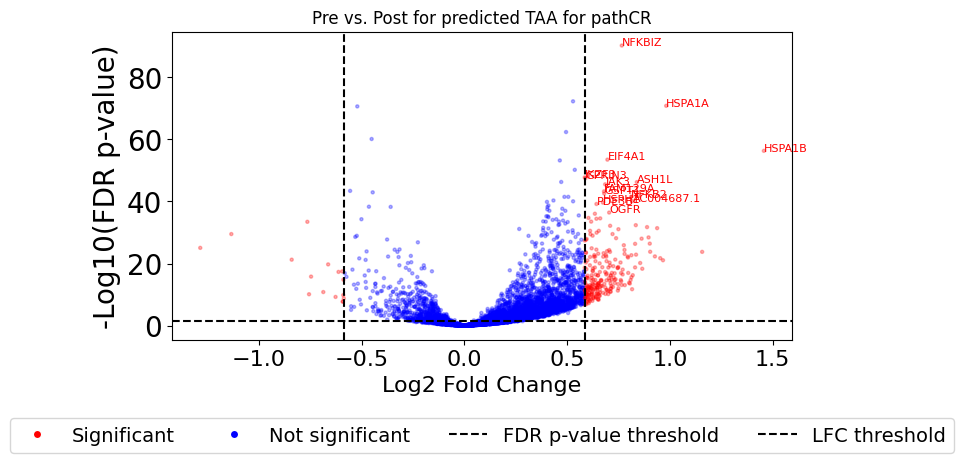

In [136]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_pre_post_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_pre_post_TAA['de_coef'], result_1d_pre_post_TAA['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_pre_post_TAA['de_coef'], -np.log10(result_1d_pre_post_TAA['pval_adj']), c=result_1d_pre_post_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_pre_post_TAA.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_pre_post_TAA[(result_1d_pre_post_TAA['color'] == "red") & (result_1d_pre_post_TAA['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('Pre vs. Post for predicted TAA for pathCR')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.5,-0.4) ,loc='lower center',ncol=4, fontsize=14)
plt.show()

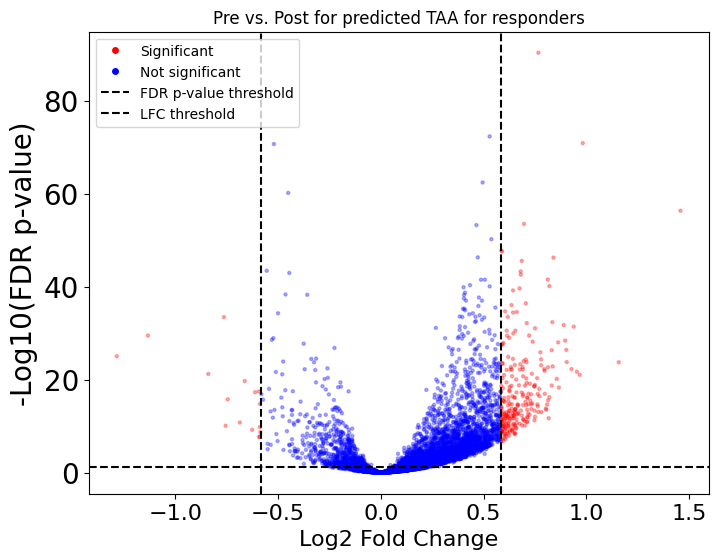

In [30]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_pre_post_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_pre_post_TAA['de_coef'], result_1d_pre_post_TAA['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_pre_post_TAA['de_coef'], -np.log10(result_1d_pre_post_TAA['pval_adj']), c=result_1d_pre_post_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d_pre_post_TAA.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d_pre_post_TAA[(result_1d_pre_post_TAA['color'] == "red") & (result_1d_pre_post_TAA['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('Pre vs. Post for predicted TAA for responders')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [ ]:
# result_1d_pre_post_TAA.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_pre_post_ref_TAA_CR.csv")

In [31]:
result_1d_pre_post_TAA[result_1d_pre_post_TAA['color'] == "red"].sort_values('de_pval', ascending=True).head(20)['gene'].values

array(['NFKBIZ', 'HSPA1A', 'HSPA1B', 'EIF4A1', 'IKZF3', 'GPRIN3', 'ASH1L',
       'JAK3', 'FAM129A', 'GSPT1', 'NFKB2', 'AC004687.1', 'HSPH1',
       'PDE3B', 'OGFR', 'GLG1', 'SLFN5', 'SNRNP70', 'PPP1R10', 'PPP1R16B'],
      dtype=object)

In [411]:
result_1d_pre_post_TAA[result_1d_pre_post_TAA['color'] == "red"].sort_values('pval_adj', ascending=True).head(20)['gene'].values

array(['EIF4A1', 'FKBP8', 'RAC1', 'FNBP1', 'ABI3', 'ATF6B', 'ZYX',
       'PNRC1', 'SNRNP70', 'TRAV38-2DV8', 'MLEC', 'TXNIP', 'LINC02195',
       'DHX36', 'KHDRBS1', 'TTN', 'NMT1', 'C6orf48', 'TMC8', 'C19orf24'],
      dtype=object)

In [32]:
cytotoxic_genes = [
    "PRF1",   # perforin
    "GZMB", "GZMA", "GZMH",  # granzymes
    "GNLY",   # granulysin
    "NKG7"
]
exhaustion_genes = [
    "PDCD1",  # PD-1
    "CTLA4",
    "LAG3",
    "TIGIT",
    "HAVCR2",  # TIM-3
    "TOX"
]
tumor_reactive = [
    "CXCL13", "PDCD1", "TOX", "ICOS", "LAG3"
]
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post, tumor_reactive, score_name="tumor_reactive")
cell_map = {'CD4T_naive2':'CD4T_naive',
 'CD4T_naive1':'CD4T_naive',
 'CD8_GrH':'CD8T_GrH',
 'CD4T_naive3':'CD4T_naive',
 'Treg':'Treg',
 'CD8T_prolif':'CD8T_prolif',
 'CD8T_GrK':'CD8T_GrK',
 'Treg1':'Treg',
 'CD8T_GrB':'CD8T_GrB',
 'CD4_Tnaive1':'CD4T_naive',
 'CD8T_GrH':'CD8T_GrH',
 'CD4_Tfh-like':'CD4_Tfh-like',
 'Treg2':'Treg',
 'gd_Tcell': 'gd_Tcell',
 'MAIT':'MAIT'}

adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['final_cell_type'] = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post.obs['cell_type_scvi'].map(cell_map)

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pre_CD40 vs. post_CD40: t-test independent samples, P_val:1.169e-20 t=-9.351e+00


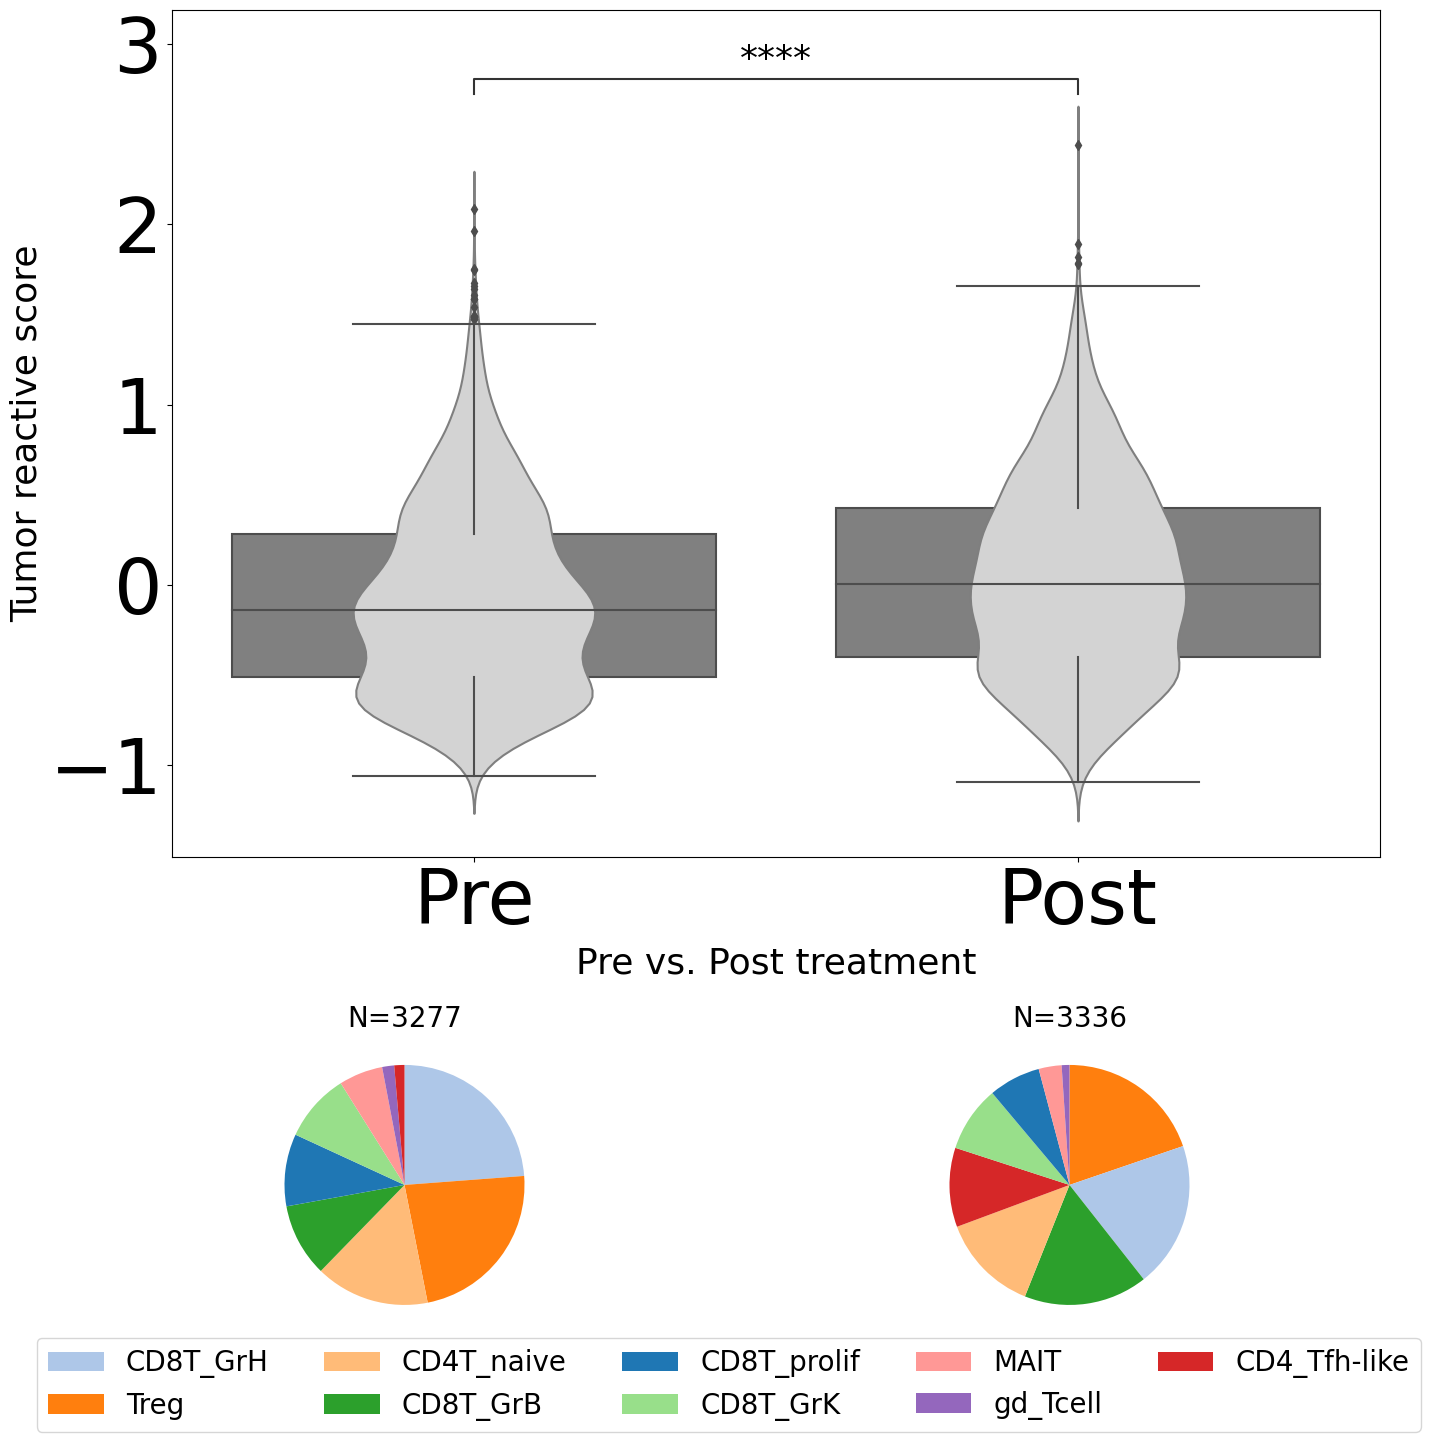

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pre_CD40","post_CD40" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post
dt_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_pre_vs_post_CR["timepoint"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_pre_vs_post_CR["timepoint"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pre_CD40","post_CD40")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pos" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="tumor_reactive",
    order=present_groups,
    # palette=palette,
    color = "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="tumor_reactive",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="tumor_reactive",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison Pre vs. Post treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("Pre vs. Post treatment", fontsize=26)
ax_box.set_ylabel("Tumor reactive score", fontsize=26)
label_map = {
    "pre_CD40": "Pre",
    "post_CD40": "Post"
}

ax_box.set_xticklabels([label_map[g] for g in present_groups])
# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_pre_vs_post_CR["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_pre_vs_post_CR["timepoint"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_pre_vs_post_CR[dt_TAA_pre_vs_post_CR["timepoint"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_pre_vs_post_CR

groups = df["timepoint"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["timepoint"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["timepoint"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive pre vs post CR within predicted TAA.csv")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pre_CD40 vs. post_CD40: t-test independent samples, P_val:4.932e-28 t=-1.103e+01


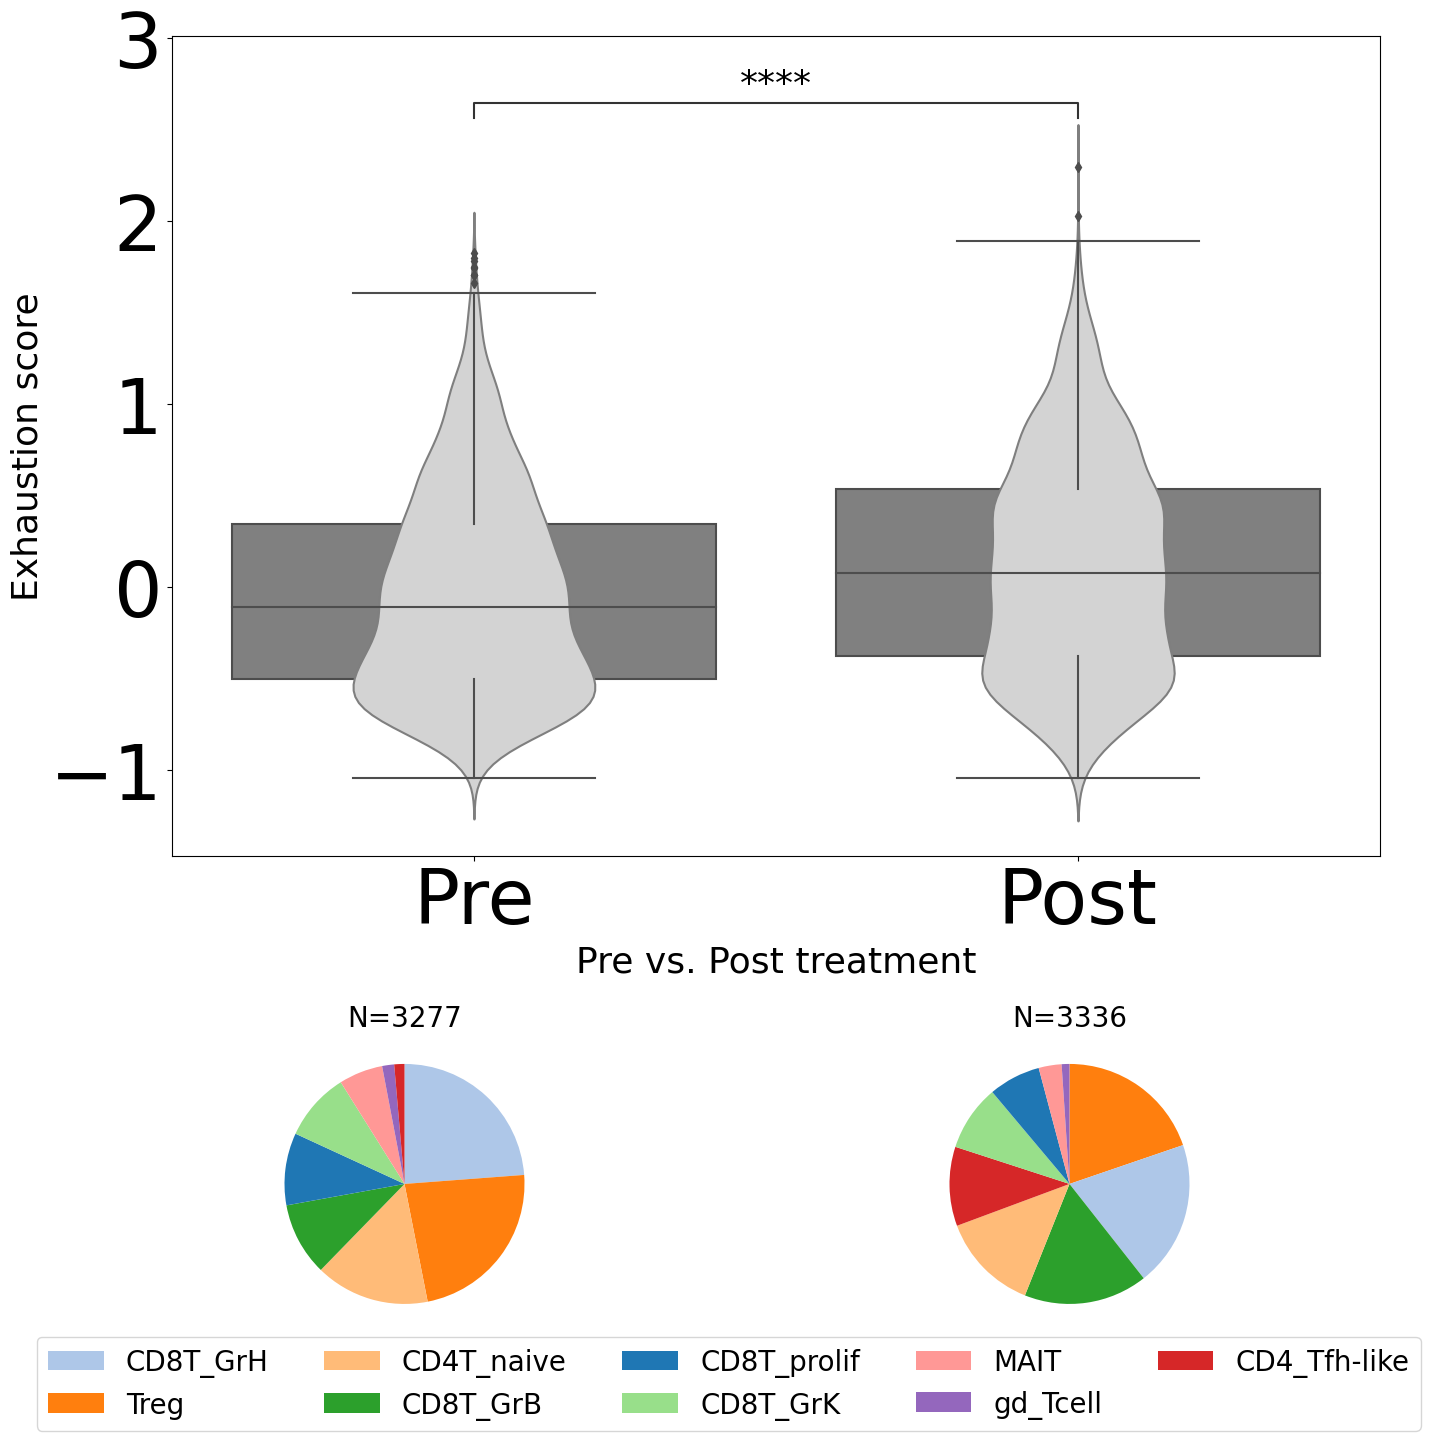

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pre_CD40","post_CD40" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post
dt_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_pre_vs_post_CR["timepoint"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_pre_vs_post_CR["timepoint"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pre_CD40","post_CD40")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pos" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="exhaustion",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="exhaustion",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="exhaustion",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison Pre vs. Post treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("Pre vs. Post treatment", fontsize=26)
ax_box.set_ylabel("Exhaustion score", fontsize=26)
label_map = {
    "pre_CD40": "Pre",
    "post_CD40": "Post"
}

ax_box.set_xticklabels([label_map[g] for g in present_groups])
# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_pre_vs_post_CR["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_pre_vs_post_CR["timepoint"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_pre_vs_post_CR[dt_TAA_pre_vs_post_CR["timepoint"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_pre_vs_post_CR

groups = df["timepoint"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["timepoint"] == g1, "exhaustion"].dropna()
    x2 = df.loc[df["timepoint"] == g2, "exhaustion"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("exhaustion pre vs post CR within predicted TAA.csv")

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



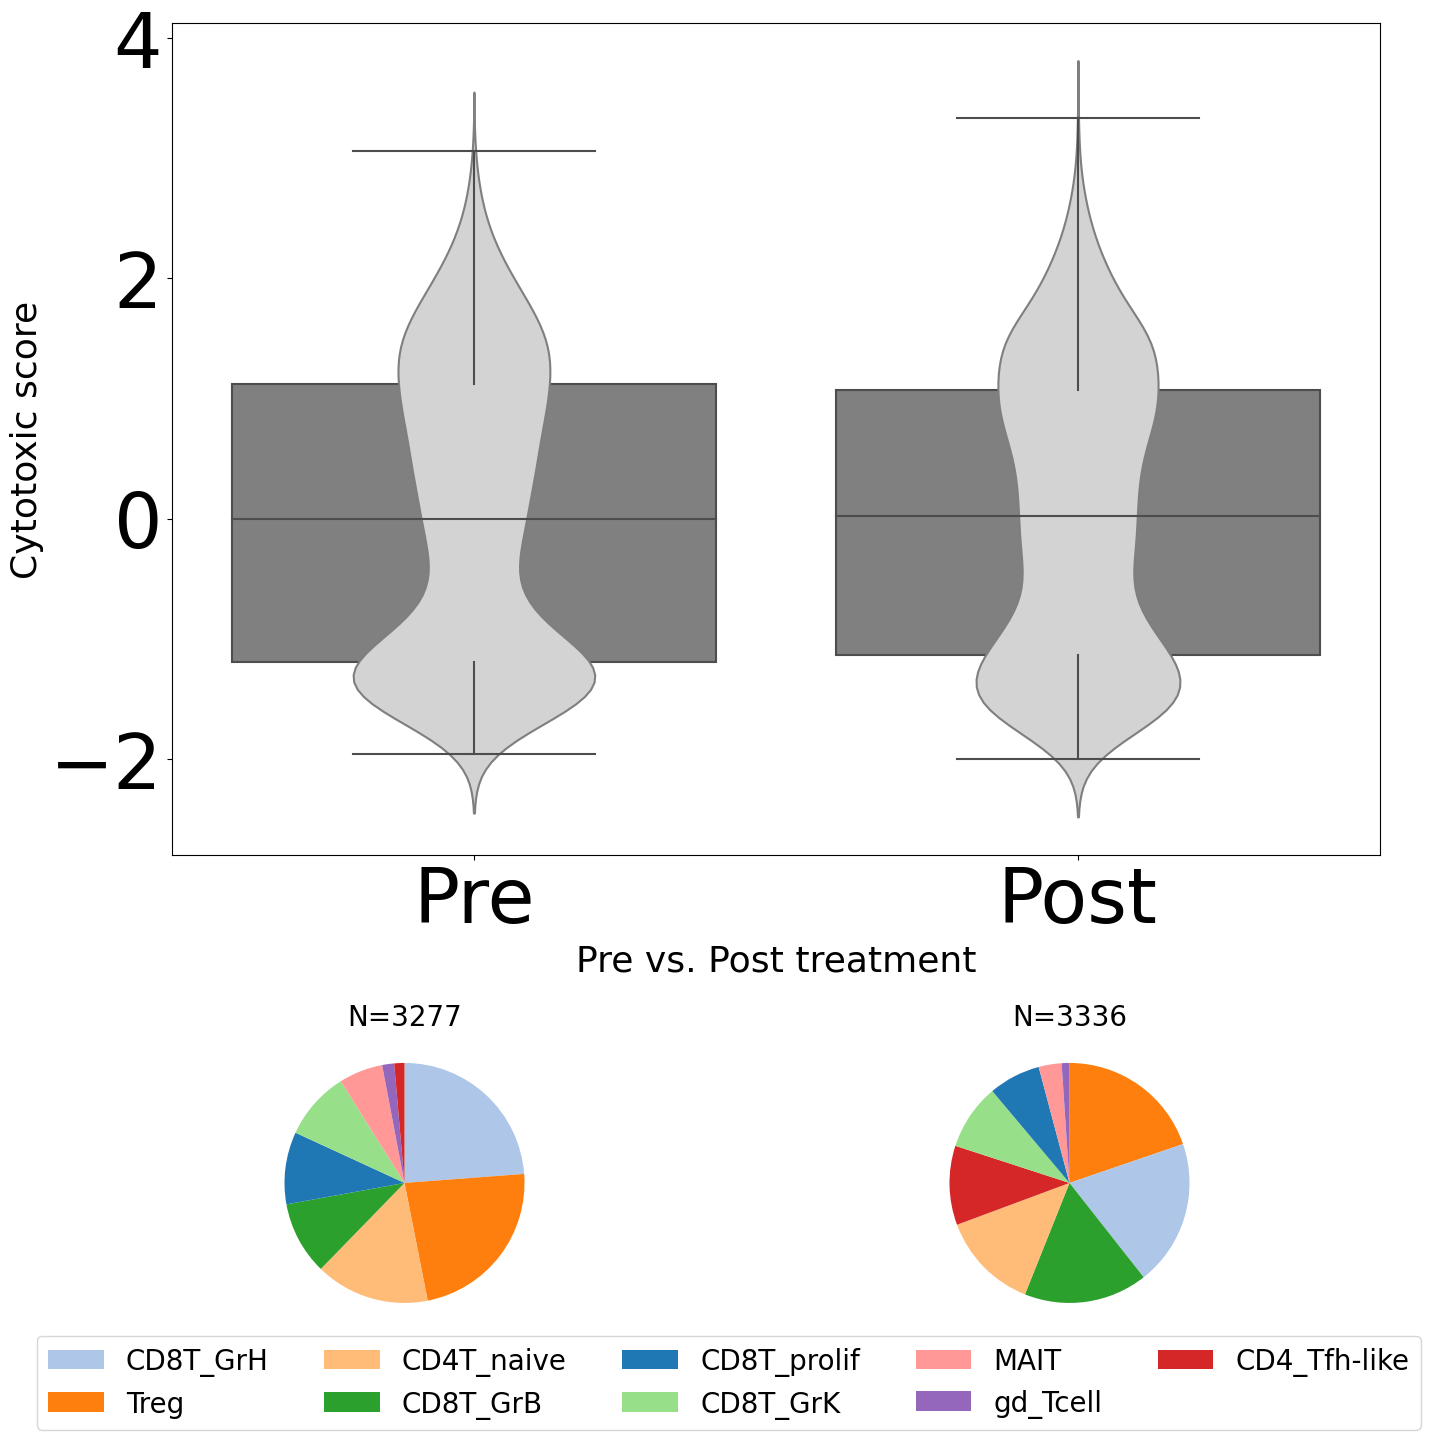

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pre_CD40","post_CD40" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_pre_post
dt_TAA_pre_vs_post_CR = adata_raw_noHC_no_NA_outcome_predicted_TAA_pre_vs_post_CR.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_pre_vs_post_CR["timepoint"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_pre_vs_post_CR["timepoint"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pre_CD40","post_CD40")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pos" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="cytotoxic",
    order=present_groups,
    # palette=palette,
    color = "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="cytotoxic",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_pre_vs_post_CR,
    x="timepoint",
    y="cytotoxic",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison Pre vs. Post treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("Pre vs. Post treatment", fontsize=26)
ax_box.set_ylabel("Cytotoxic score", fontsize=26)
label_map = {
    "pre_CD40": "Pre",
    "post_CD40": "Post"
}

ax_box.set_xticklabels([label_map[g] for g in present_groups])
# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_pre_vs_post_CR["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_pre_vs_post_CR["timepoint"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_pre_vs_post_CR[dt_TAA_pre_vs_post_CR["timepoint"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_pre_vs_post_CR

groups = df["timepoint"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["timepoint"] == g1, "cytotoxic"].dropna()
    x2 = df.loc[df["timepoint"] == g2, "cytotoxic"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("cytotoxic pre vs post CR within predicted TAA.csv")

# CR vs PD for predicted TAA

In [37]:
adata_raw_noHC_no_NA_outcome_high_conf.obs['response'].value_counts()

response
pathCR      7009
HD          1111
nopathCR     814
Name: count, dtype: int64

In [38]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR = adata_raw_noHC_no_NA_outcome_high_conf[adata_raw_noHC_no_NA_outcome_high_conf.obs['response'].str.contains("pathCR|nopathPD")]
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR

View of AnnData object with n_obs × n_vars = 7823 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp'
    obsm: 'X_umap'
    layers: 'counts'

In [39]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.obs['outcome_ref_PD'] = (adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.obs['outcome'] != "PD") + 0

/var/folders/xy/jbfzznj17w73w_rdfj3xs11h0000gn/T/ipykernel_43569/3085858280.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.obs['outcome_ref_PD'] = (adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.obs['outcome'] != "PD") + 0


In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.write("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.h5ad")


In [41]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.h5ad")

In [73]:
result_1d_CR_PD_TAA = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR, 
    capture_rate=0.07, 
    treatment_col='outcome_ref_PD', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    7.1s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:   27.2s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:  1.0min
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:  1.8min
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:  2.8min
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:  4.0min
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:  5.7min
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:  7.6min
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:  9.7min
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed: 12.2min
[Parallel(n_job

In [ ]:
# result_1d_CR_PD_TAA.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_pathCR_vs_nopathCR_TAA.csv")

In [ ]:
# result_1d_CR_PD_TAA  = pd.read_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_vs_PD_TAA.csv")

In [76]:
result_1d_CR_PD_TAA["pval_adj"] = multipletests(result_1d_CR_PD_TAA["de_pval"], method="fdr_bh")[1]

In [82]:
result_1d_CR_PD_TAA[result_1d_CR_PD_TAA['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['FOS', 'LINC01871', 'GZMB', 'HSPA1B', 'HSPA1A', 'PRF1', 'ID2',
       'MX1', 'CTLA4', 'IFI6', 'TRBV7-9', 'FOSB', 'BLOC1S1', 'KLF2',
       'IFI44L'], dtype=object)

In [78]:
from statsmodels.stats.multitest import multipletests

In [79]:
result_1d_CR_PD_TAA["pval_adj"] = multipletests(result_1d_CR_PD_TAA["de_pval"], method="fdr_bh")[1]

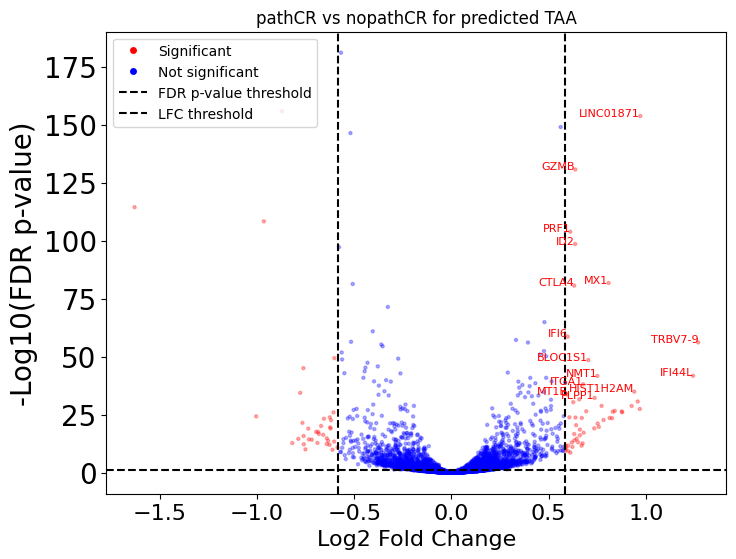

In [132]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA['de_coef'], result_1d_CR_PD_TAA['de_pval'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA['de_coef'], -np.log10(result_1d_CR_PD_TAA['de_pval']), c=result_1d_CR_PD_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['de_pval'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA[(result_1d_CR_PD_TAA['color'] == "red") & (result_1d_CR_PD_TAA['de_coef'] > 0)].sort_values('de_pval', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['de_pval']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('pathCR vs nopathCR for predicted TAA')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

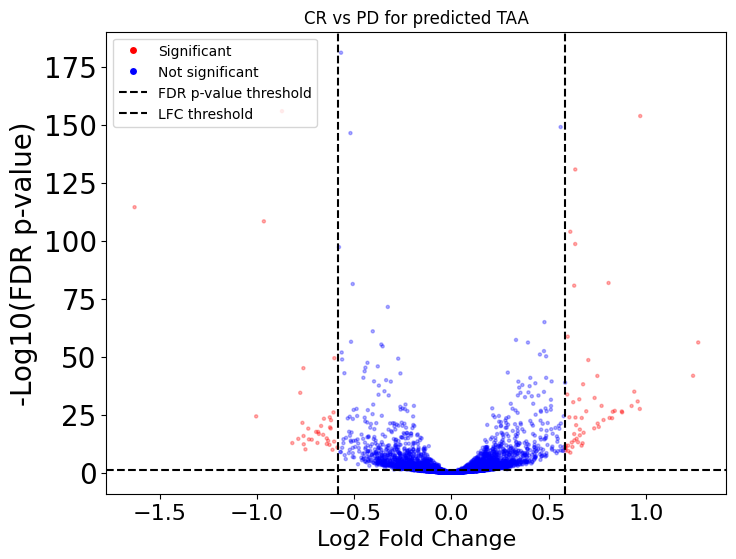

In [81]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA['de_coef'], result_1d_CR_PD_TAA['de_pval'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA['de_coef'], -np.log10(result_1d_CR_PD_TAA['de_pval']), c=result_1d_CR_PD_TAA['color'], alpha=0.3, s=5) # s is the size of the dots

# # Highlight significant genes by annotating them
# for i, row in result_1d_CR_PD_TAA.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['de_pval'] < pval_threshold:
#         if row['gene'] in result_1d_CR_PD_TAA[(result_1d_CR_PD_TAA['color'] == "red") & (result_1d_CR_PD_TAA['de_coef'] > 0)].sort_values('de_pval', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['de_pval']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs PD for predicted TAA')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

# Compare CR vs. PD for pre-treatment

In [43]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR[adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.obs['timepoint'].str.contains("pre")].copy()
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre

AnnData object with n_obs × n_vars = 3823 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp', 'outcome_ref_PD'
    obsm: 'X_umap'
    layers: 'counts'

In [86]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['outcome_ref_nopathCR'] = (adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['response'] != "nopathCR") + 0

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.write("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.h5ad")

In [87]:
result_1d_CR_PD_TAA_pre_treatment = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre, 
    capture_rate=0.07, 
    treatment_col='outcome_ref_nopathCR', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    6.9s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:   19.3s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:   41.0s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:  1.2min
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:  1.9min
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:  2.6min
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:  3.7min
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:  5.0min
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:  6.5min
[Parallel(n_jobs=6)]: Done 4988 tasks      | elapsed:  8.1min
[Parallel(n_job

In [88]:
result_1d_CR_PD_TAA_pre_treatment

,gene,tx,de_coef,de_se,de_pval,dv_coef,dv_se,dv_pval
0,NOC2L,outcome_ref_nopathCR,-0.425100,0.113664,1.677023e-04,0.297042,0.336168,0.476033
1,ISG15,outcome_ref_nopathCR,0.571708,0.067074,2.215550e-17,0.047775,0.205115,0.914197
2,TNFRSF18,outcome_ref_nopathCR,0.776877,0.098192,3.552449e-15,0.271506,0.179560,0.173883
3,TNFRSF4,outcome_ref_nopathCR,0.490107,0.097652,6.047616e-07,0.291937,0.105631,0.006893
4,SDF4,outcome_ref_nopathCR,0.126139,0.060516,3.768652e-02,1.244133,0.882930,0.230424
...,...,...,...,...,...,...,...,...
5888,MCM3AP,outcome_ref_nopathCR,-0.883037,0.124715,1.374902e-12,0.613854,0.356965,0.124764
5889,YBEY,outcome_ref_nopathCR,0.527885,0.191444,7.078174e-03,-0.261135,0.354721,0.355355
5890,PCNT,outcome_ref_nopathCR,-0.719144,0.160502,5.914453e-06,0.019237,0.291619,0.897289
5891,DIP2A,outcome_ref_nopathCR,-0.285306,0.096718,3.007114e-03,0.852191,0.263899,0.002583


In [ ]:
# result_1d_CR_PD_TAA_pre_treatment.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_pathCR_nopathCR_TAA_pre_treatment.csv")

In [126]:
result_1d_CR_PD_TAA_pre_treatment_no_path = pd.read_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_PD_TAA_pre_treatment.csv")
result_1d_CR_PD_TAA_pre_treatment_no_path
result_1d_CR_PD_TAA_pre_treatment_nopath_sort = result_1d_CR_PD_TAA_pre_treatment_no_path.sort_values(['de_coef'], ascending = False).copy()
result_1d_CR_PD_TAA_pre_treatment_sort = result_1d_CR_PD_TAA_pre_treatment.sort_values(['de_coef'], ascending = False).copy()
set(result_1d_CR_PD_TAA_pre_treatment_sort.gene.values[0:100]).intersection(result_1d_CR_PD_TAA_pre_treatment_nopath_sort.gene[0:100])

{'AC243829.4',
 'CMPK2',
 'ETV7',
 'GMNN',
 'GSTP1',
 'HLA-DQA1',
 'IFI44L',
 'LAYN',
 'LGALS1',
 'LGALS3',
 'LINC01871',
 'MX1',
 'NMT1',
 'OAS1',
 'OAS3',
 'SOX4',
 'SPATS2L',
 'TRAV38-2DV8',
 'TRBV7-2',
 'TRBV7-9',
 'TYMS',
 'UBE2T'}

In [129]:
result_1d_CR_PD_TAA_pre_treatment_sort.head(20)

,gene,tx,de_coef,de_se,de_pval,dv_coef,dv_se,dv_pval,pval_adj,color
500,AL157402.2,outcome_ref_nopathCR,2.001738,0.179380,3.629266e-28,0.228298,0.343739,6.540544e-01,2.275241e-26,red
4056,TRAV38-2DV8,outcome_ref_nopathCR,1.407955,0.219782,3.463728e-10,-0.131257,0.090898,1.578678e-01,2.570749e-09,red
2410,TRBV7-9,outcome_ref_nopathCR,1.076144,0.187066,1.685620e-08,-0.159596,0.091406,8.360170e-02,9.551305e-08,red
452,XCL1,outcome_ref_nopathCR,1.030301,0.251713,7.251554e-05,-0.574193,0.148343,1.068634e-04,2.122872e-04,red
766,CAPG,outcome_ref_nopathCR,1.012783,0.095383,2.901319e-26,0.487684,0.135513,4.028590e-04,1.597895e-24,red
307,RHOC,outcome_ref_nopathCR,0.988868,0.096161,7.693888e-25,0.076164,0.259915,8.820306e-01,3.542194e-23,red
5112,SEC11C,outcome_ref_nopathCR,0.948143,0.119534,3.056166e-15,-0.882878,0.138994,1.641499e-10,4.606134e-14,red
823,AC017002.3,outcome_ref_nopathCR,0.944025,0.171258,6.920143e-08,-0.016467,0.424169,7.825579e-01,3.561607e-07,red
3562,AFAP1L2,outcome_ref_nopathCR,0.927074,0.193439,2.183983e-06,0.123475,0.274604,7.320328e-01,8.545956e-06,red
4910,HOXB2,outcome_ref_nopathCR,0.917395,0.156233,6.054120e-09,0.409377,0.320071,2.621561e-01,3.662929e-08,red


In [89]:
result_1d_CR_PD_TAA_pre_treatment["pval_adj"] = multipletests(result_1d_CR_PD_TAA_pre_treatment["de_pval"], method="fdr_bh")[1]

In [91]:
result_1d_CR_PD_TAA_pre_treatment[result_1d_CR_PD_TAA_pre_treatment['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['HSPH1', 'HSPA1B', 'HSPA1A', 'AHNAK', 'ZC3HAV1', 'SLC2A3', 'SKIL',
       'AHSA1', 'HSPD1', 'TAGAP', 'TC2N', 'RNF125', 'SLFN5', 'CHD2',
       'KDM6B'], dtype=object)

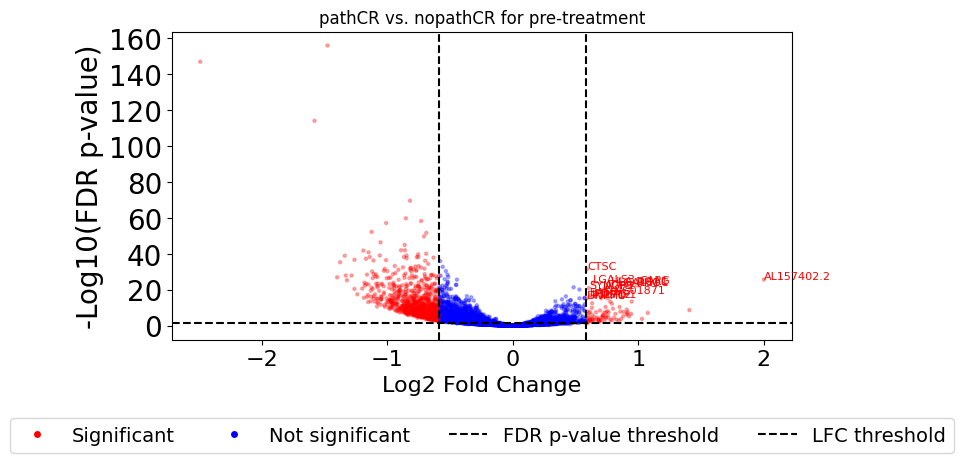

In [133]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_pre_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_pre_treatment['de_coef'], result_1d_CR_PD_TAA_pre_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_CR_PD_TAA_pre_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_pre_treatment['pval_adj']), c=result_1d_CR_PD_TAA_pre_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA_pre_treatment.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA_pre_treatment[(result_1d_CR_PD_TAA_pre_treatment['color'] == "red") & (result_1d_CR_PD_TAA_pre_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('pathCR vs. nopathCR for pre-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.5,-0.4) ,loc='lower center',ncol=4, fontsize=14)
plt.show()

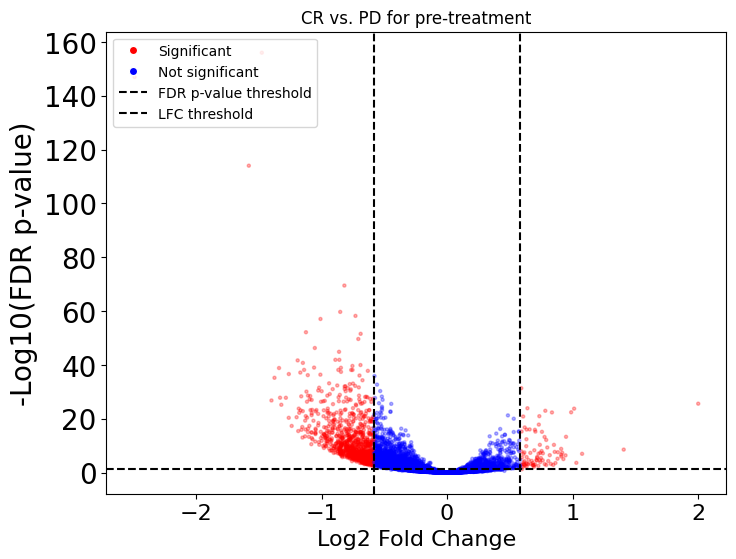

In [93]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_pre_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_pre_treatment['de_coef'], result_1d_CR_PD_TAA_pre_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA_pre_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_pre_treatment['pval_adj']), c=result_1d_CR_PD_TAA_pre_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d_CR_PD_TAA_pre_treatment.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d_CR_PD_TAA_pre_treatment[(result_1d_CR_PD_TAA_pre_treatment['color'] == "red") & (result_1d_CR_PD_TAA_pre_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for pre-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [94]:
result_1d_CR_PD_TAA_pre_treatment[result_1d_CR_PD_TAA_pre_treatment['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['HSPH1', 'HSPA1B', 'HSPA1A', 'AHNAK', 'ZC3HAV1', 'SLC2A3', 'SKIL',
       'AHSA1', 'HSPD1', 'TAGAP', 'TC2N', 'RNF125', 'SLFN5', 'CHD2',
       'KDM6B'], dtype=object)

In [495]:
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD.h5ad")

In [496]:
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD

AnnData object with n_obs × n_vars = 845 × 64
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'tissue', 'final_cell_type', 'leiden', 'outcome_order', 'IFN_score', 'cytotoxic', 'exhaustion', 'tumor_reactive', 'nk_killing', 'match', 'category', 'tumor_pred', 'tumor_pred_cat'
    uns: 'final_cell_type_colors', 'leiden', 'leiden_colors', 'match_colors', 'neighbors', 'outcome_colors', 'outcome_order_colors', 'patient_colors', 'pca', 'response_colors', 'timepoint_colors', 'tumor_pred_cat_colors', 'tumor_pred_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [45]:
cytotoxic_genes = [
    "PRF1",   # perforin
    "GZMB", "GZMA", "GZMH",  # granzymes
    "GNLY",   # granulysin
    "NKG7"
]
exhaustion_genes = [
    "PDCD1",  # PD-1
    "CTLA4",
    "LAG3",
    "TIGIT",
    "HAVCR2",  # TIM-3
    "TOX"
]
tumor_reactive = [
    "CXCL13", "PDCD1", "TOX", "ICOS", "LAG3"
]
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre, tumor_reactive, score_name="tumor_reactive")
cell_map = {'CD4T_naive2':'CD4T_naive',
 'CD4T_naive1':'CD4T_naive',
 'CD8_GrH':'CD8T_GrH',
 'CD4T_naive3':'CD4T_naive',
 'Treg':'Treg',
 'CD8T_prolif':'CD8T_prolif',
 'CD8T_GrK':'CD8T_GrK',
 'Treg1':'Treg',
 'CD8T_GrB':'CD8T_GrB',
 'CD4_Tnaive1':'CD4T_naive',
 'CD8T_GrH':'CD8T_GrH',
 'CD4_Tfh-like':'CD4_Tfh-like',
 'Treg2':'Treg',
 'gd_Tcell': 'gd_Tcell',
 'MAIT':'MAIT'}

adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['final_cell_type'] = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['cell_type_scvi'].map(cell_map)

In [46]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre

AnnData object with n_obs × n_vars = 3823 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp', 'outcome_ref_PD', 'cytotoxic', 'exhaustion', 'tumor_reactive', 'final_cell_type'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.write_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.h5ad")

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.h5ad")

In [ ]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['response'].value_counts()

response
pathCR      3277
nopathCR     546
Name: count, dtype: int64

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



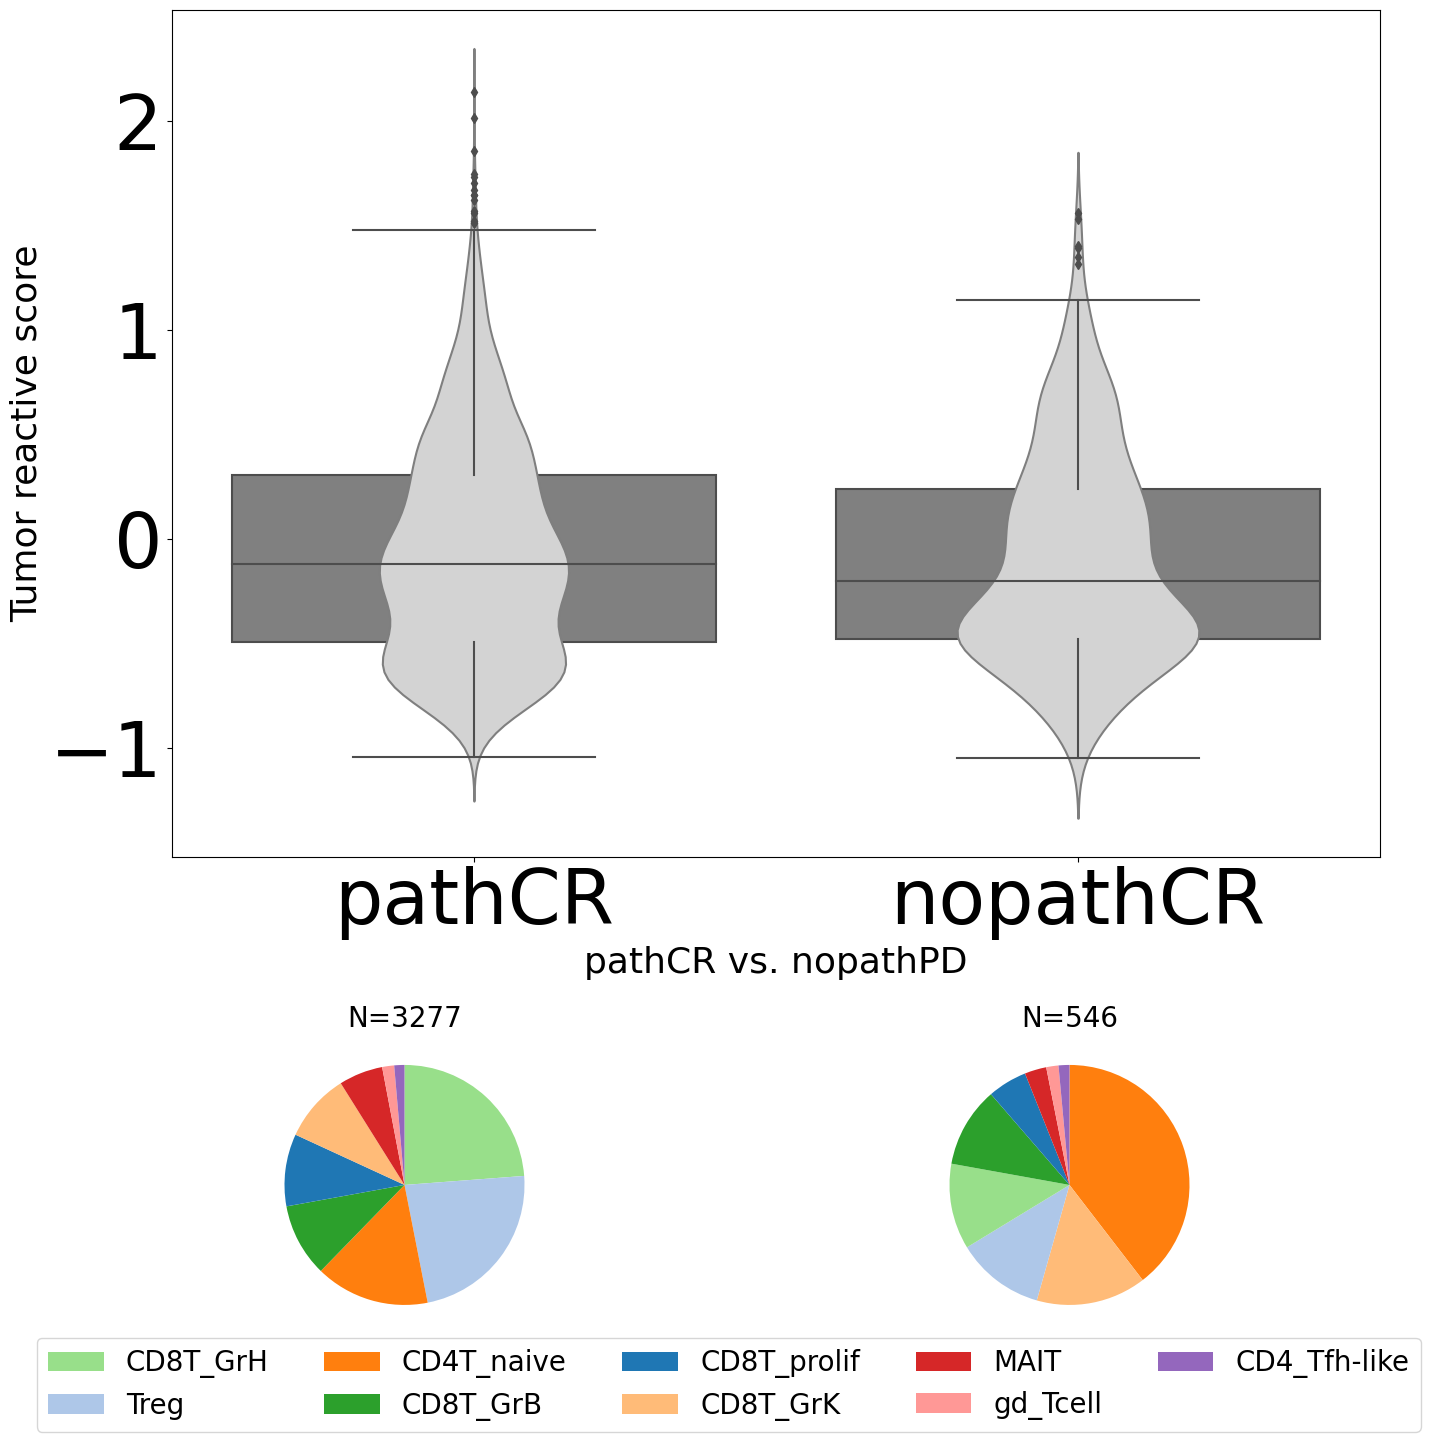

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,pathCR,nopathCR,3277,546,-0.055697,-0.095051,1.658828,0.097567,0.097567


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pathCR","nopathCR" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre[adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['timepoint'].str.contains("pre")]
dt_TAA_CR_PD_pretreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_pretreatment["response"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_pretreatment["response"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pathCR","nopathCR")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pathCR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="tumor_reactive",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="tumor_reactive",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="tumor_reactive",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for pre treatment within predicted TAA cells", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("pathCR vs. nopathPD", fontsize=26)
ax_box.set_ylabel("Tumor reactive score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_pretreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_pretreatment["response"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_pretreatment[dt_TAA_CR_PD_pretreatment["response"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["response"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["response"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["response"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD pre treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pathCR vs. nopathCR: t-test independent samples, P_val:1.205e-08 t=5.712e+00


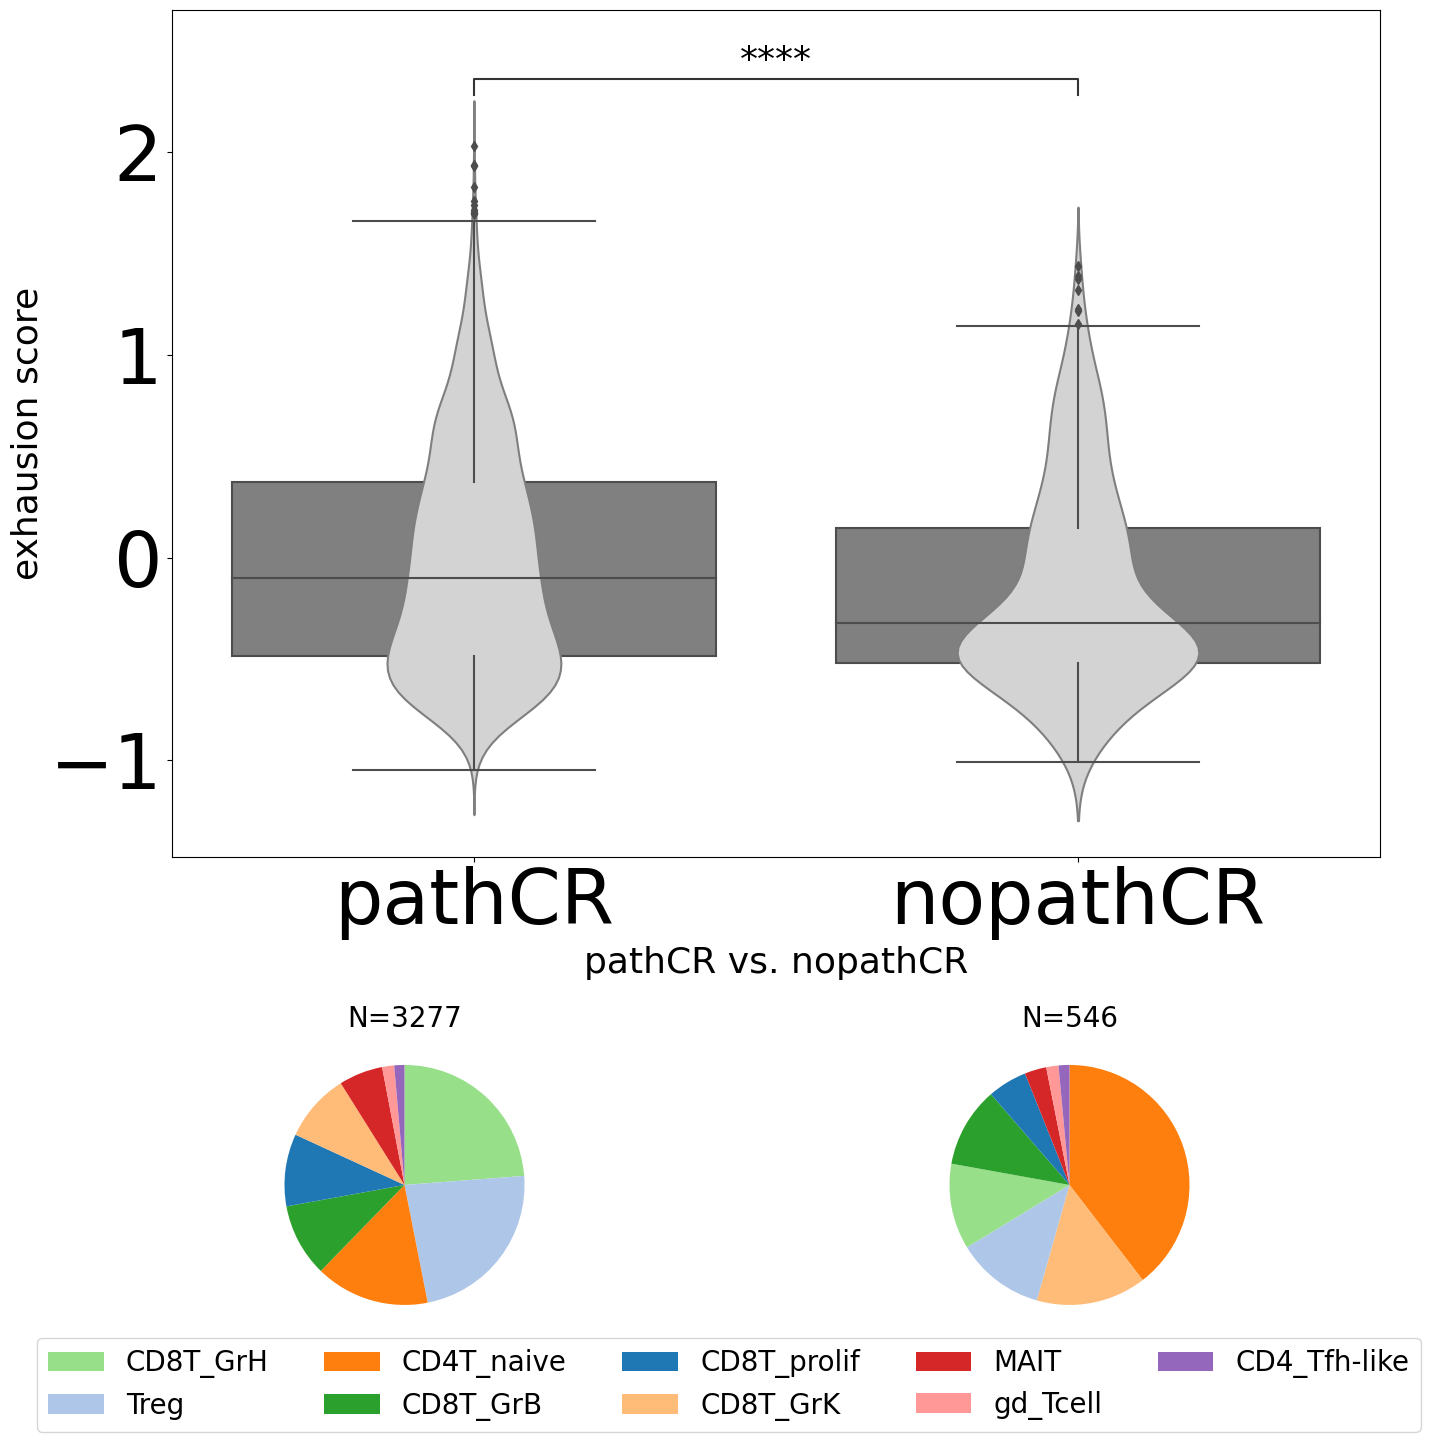

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,pathCR,nopathCR,3277,546,-0.055697,-0.095051,1.658828,0.097567,0.097567


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pathCR","nopathCR" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre[adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['timepoint'].str.contains("pre")]
dt_TAA_CR_PD_pretreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_pretreatment["response"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_pretreatment["response"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pathCR","nopathCR")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pathCR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="exhaustion",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="exhaustion",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="exhaustion",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for pre treatment within predicted TAA cells", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("pathCR vs. nopathCR", fontsize=26)
ax_box.set_ylabel("exhausion score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_pretreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_pretreatment["response"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_pretreatment[dt_TAA_CR_PD_pretreatment["response"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["response"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["response"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["response"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD pre treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pathCR vs. nopathCR: t-test independent samples, P_val:1.326e-13 t=7.431e+00


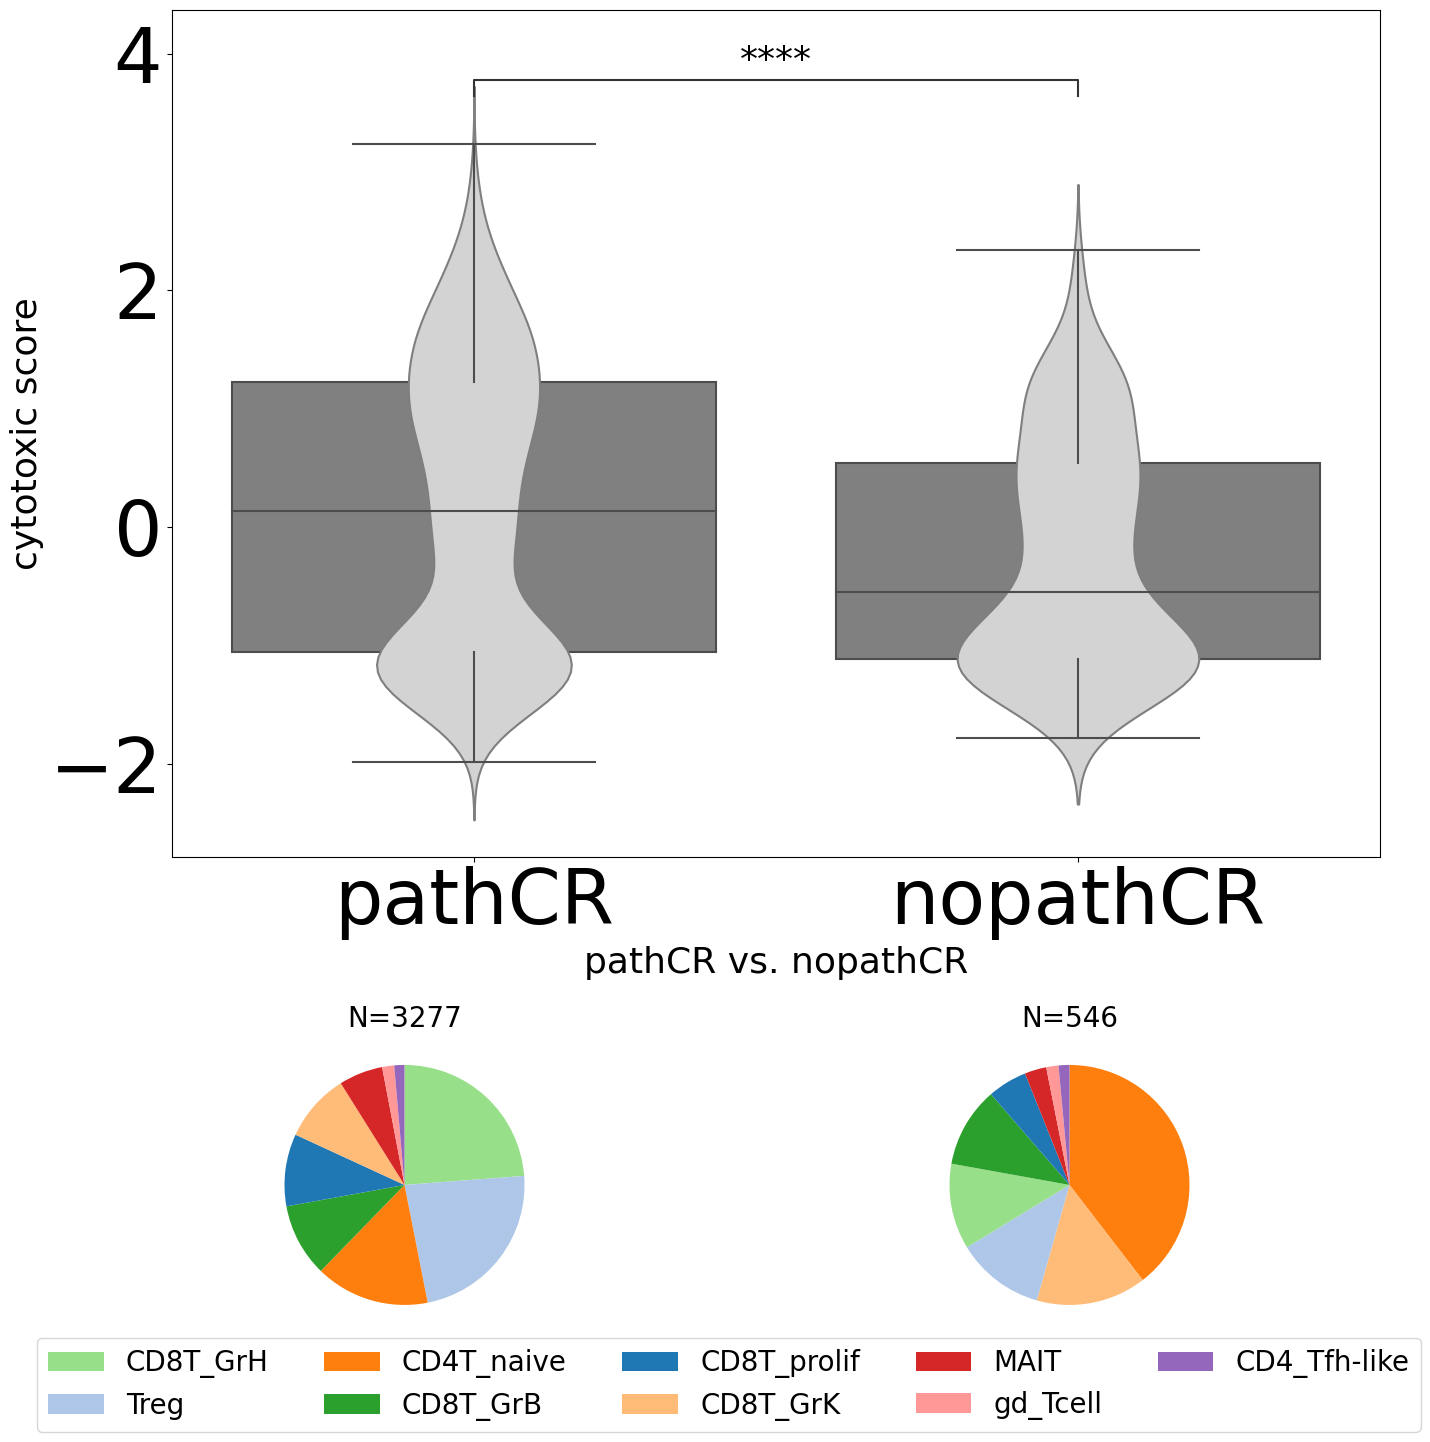

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,pathCR,nopathCR,3277,546,-0.055697,-0.095051,1.658828,0.097567,0.097567


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pathCR","nopathCR" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre[adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_pre.obs['timepoint'].str.contains("pre")]
dt_TAA_CR_PD_pretreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_pre.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_pretreatment["response"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_pretreatment["response"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pathCR","nopathCR")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pathCR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="cytotoxic",
    order=present_groups,
    # palette=palette,
    color="grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="cytotoxic",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_pretreatment,
    x="response",
    y="cytotoxic",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for pre treatment within predicted TAA cells", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("pathCR vs. nopathCR", fontsize=26)
ax_box.set_ylabel("cytotoxic score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_pretreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_pretreatment["response"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_pretreatment[dt_TAA_CR_PD_pretreatment["response"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["response"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["response"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["response"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD pre treatment within predicted TAA.csv")
results_df

# Compare CR vs. PD for post treatment

In [63]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR[adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR.obs['timepoint'].str.contains("post")].copy()
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post

AnnData object with n_obs × n_vars = 3402 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp', 'outcome_ref_PD'
    obsm: 'X_umap'
    layers: 'counts'

In [ ]:
# adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.write("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.h5ad")


In [96]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.obs['outcome_ref_nopathCR'] = (adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.obs['response'] != "nopathCR") + 0

In [65]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post = sc.read_h5ad("adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.h5ad")

In [97]:
result_1d_CR_PD_TAA_post_treatment = memento.binary_test_1d(
    adata=adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post, 
    capture_rate=0.07, 
    treatment_col='outcome_ref_nopathCR', 
    num_cpus=6,
    num_boot=5000)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    4.4s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:   15.6s
[Parallel(n_jobs=6)]: Done 438 tasks      | elapsed:   39.6s
[Parallel(n_jobs=6)]: Done 788 tasks      | elapsed:  1.2min
[Parallel(n_jobs=6)]: Done 1238 tasks      | elapsed:  1.8min
[Parallel(n_jobs=6)]: Done 1788 tasks      | elapsed:  2.6min
[Parallel(n_jobs=6)]: Done 2438 tasks      | elapsed:  3.7min
[Parallel(n_jobs=6)]: Done 3188 tasks      | elapsed:  5.1min
[Parallel(n_jobs=6)]: Done 4038 tasks      | elapsed:  6.5min
[Parallel(n_jobs=6)]: Done 4777 out of 4777 | elapsed:  7.8min finished


In [ ]:
# result_1d_CR_PD_TAA_post_treatment.to_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_pathCR_nopathCR_TAA_post_treatment.csv")

In [131]:
result_1d_CR_PD_TAA_post_treatment_no_path = pd.read_csv("adata_raw_noHC_no_NA_outcome_high_conf_result_1d_CR_PD_TAA_post_treatment.csv")
result_1d_CR_PD_TAA_post_treatment_no_path
result_1d_CR_PD_TAA_post_treatment_no_path_sort = result_1d_CR_PD_TAA_post_treatment_no_path.sort_values(['de_coef'], ascending = False).copy()
result_1d_CR_PD_TAA_post_treatment_sort = result_1d_CR_PD_TAA_post_treatment.sort_values(['de_coef'], ascending = False).copy()
set(result_1d_CR_PD_TAA_post_treatment_sort.gene.values[0:100]).intersection(result_1d_CR_PD_TAA_post_treatment_no_path_sort.gene[0:100])

{'APOBEC3C', 'BLOC1S1', 'CTSW', 'GZMB', 'ITM2C', 'LINC01871', 'PRF1'}

In [130]:
result_1d_CR_PD_TAA_post_treatment_sort.head(20)

,gene,tx,de_coef,de_se,de_pval,dv_coef,dv_se,dv_pval,pval_adj,color
4690,APOBEC3G,outcome_ref_nopathCR,2.597618,0.696441,0.000598,0.649727,0.765760,7.309164e-01,0.019305,red
656,CD8A,outcome_ref_nopathCR,2.356066,0.558462,0.000087,2.345749,0.211941,9.032974e-29,0.004032,red
1022,TIGIT,outcome_ref_nopathCR,2.343986,0.548111,0.000065,0.422934,0.316798,1.289623e-01,0.003243,red
4401,ACP5,outcome_ref_nopathCR,2.227672,0.621040,0.000964,0.710187,0.387701,1.047503e-01,0.029137,red
3360,GZMB,outcome_ref_nopathCR,2.139609,0.467732,0.000015,2.908231,0.163932,1.036549e-70,0.000926,red
2596,LPXN,outcome_ref_nopathCR,2.084189,0.689396,0.006287,-1.132547,0.697474,8.087454e-02,0.121584,blue
4265,CTSA,outcome_ref_nopathCR,2.062269,0.634886,0.002826,0.201896,0.397587,6.894408e-01,0.068874,blue
2673,CDK2AP2,outcome_ref_nopathCR,2.016329,0.528767,0.000509,0.192669,0.392534,6.608839e-01,0.016994,red
4501,ACTN4,outcome_ref_nopathCR,2.007267,0.515582,0.000290,0.440954,0.379387,2.280259e-01,0.010706,red
4280,UBE2V1,outcome_ref_nopathCR,1.999881,0.650908,0.006215,-0.455580,0.632172,3.608839e-01,0.120687,blue


In [98]:
result_1d_CR_PD_TAA_post_treatment["pval_adj"] = multipletests(result_1d_CR_PD_TAA_post_treatment["de_pval"], method="fdr_bh")[1]

In [448]:
result_1d_CR_PD_TAA_post_treatment[result_1d_CR_PD_TAA_post_treatment['color'] == "red"].sort_values('pval_adj', ascending=True).head(15)['gene'].values

array(['ID2', 'TRAV38-2DV8', 'TRBV7-9', 'EIF4A1', 'HSPA1A', 'HSPA1B',
       'LINC01871', 'BLOC1S1', 'APOBEC3C', 'HSPH1', 'SQSTM1', 'GSTP1',
       'ISG15', 'ABI3', 'RANBP1'], dtype=object)

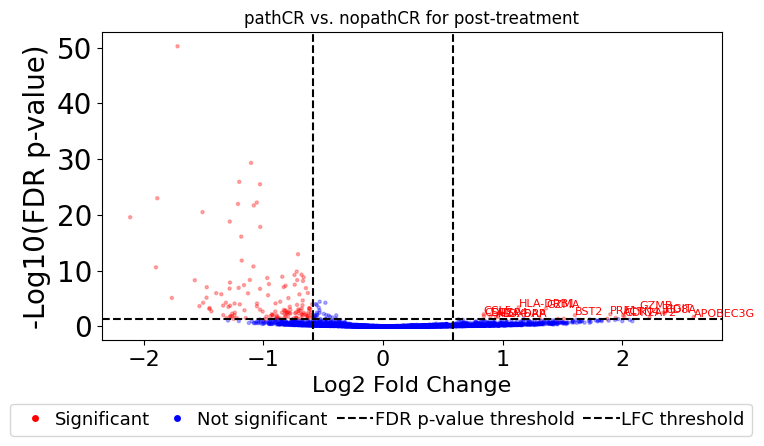

In [134]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_post_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_post_treatment['de_coef'], result_1d_CR_PD_TAA_post_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_CR_PD_TAA_post_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_post_treatment['pval_adj']), c=result_1d_CR_PD_TAA_post_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA_post_treatment.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA_post_treatment[(result_1d_CR_PD_TAA_post_treatment['color'] == "red") & (result_1d_CR_PD_TAA_post_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('pathCR vs. nopathCR for post-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.45,-0.34) ,loc='lower center',ncol=4, fontsize=13,columnspacing=0.5,handletextpad=0.1)
plt.show()

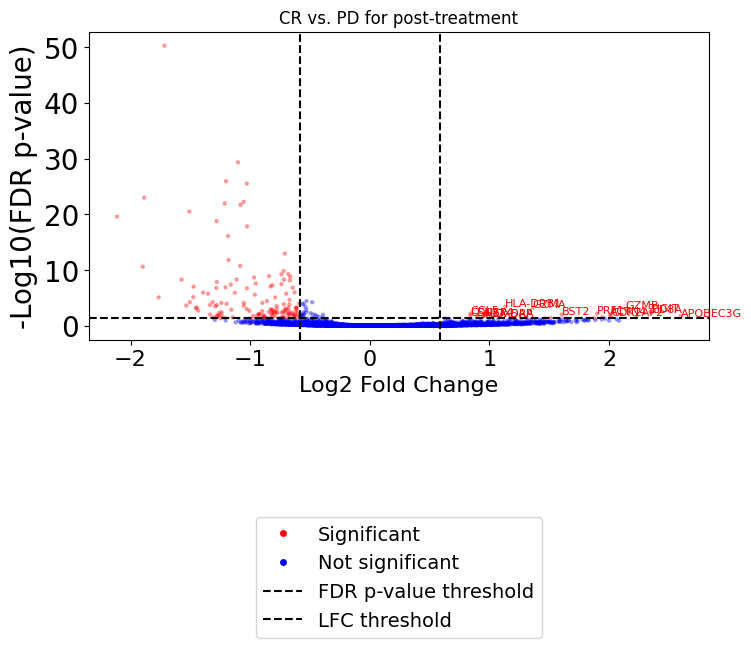

In [100]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_post_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_post_treatment['de_coef'], result_1d_CR_PD_TAA_post_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 4))
plt.scatter(result_1d_CR_PD_TAA_post_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_post_treatment['pval_adj']), c=result_1d_CR_PD_TAA_post_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
for i, row in result_1d_CR_PD_TAA_post_treatment.iterrows():
    if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
        if row['gene'] in result_1d_CR_PD_TAA_post_treatment[(result_1d_CR_PD_TAA_post_treatment['color'] == "red") & (result_1d_CR_PD_TAA_post_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
            plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='left', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for post-treatment')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, bbox_to_anchor = (0.5,-1) ,loc='lower center',ncol=1, fontsize=14)
plt.show()

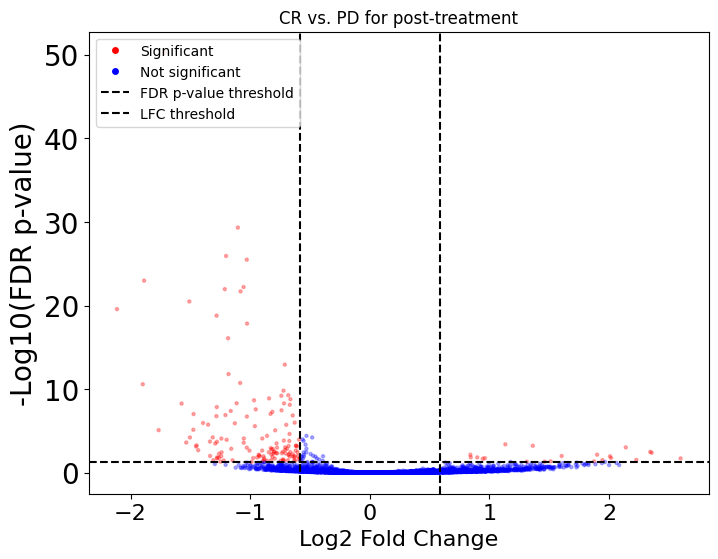

In [101]:
lfc_threshold = math.log2(1.5)  # Log2 fold change threshold
pval_threshold = 0.05

# Assign colors based on significance
result_1d_CR_PD_TAA_post_treatment['color'] = ['red' if abs(lfc) > lfc_threshold and pval < pval_threshold else 'blue' 
                 for lfc, pval in zip(result_1d_CR_PD_TAA_post_treatment['de_coef'], result_1d_CR_PD_TAA_post_treatment['pval_adj'])]

# Plot volcano plot
plt.figure(figsize=(8, 6))
plt.scatter(result_1d_CR_PD_TAA_post_treatment['de_coef'], -np.log10(result_1d_CR_PD_TAA_post_treatment['pval_adj']), c=result_1d_CR_PD_TAA_post_treatment['color'], alpha=0.3, s=5) # s is the size of the dots

# Highlight significant genes by annotating them
# for i, row in result_1d_CR_PD_TAA_post_treatment.iterrows():
#     if abs(row['de_coef']) > lfc_threshold and row['pval_adj'] < pval_threshold:
#         if row['gene'] in result_1d_CR_PD_TAA_post_treatment[(result_1d_CR_PD_TAA_post_treatment['color'] == "red") & (result_1d_CR_PD_TAA_post_treatment['de_coef'] > 0)].sort_values('pval_adj', ascending=True).head(15)['gene'].values:
#             plt.text(row['de_coef'], -np.log10(row['pval_adj']), row['gene'], fontsize=8, ha='right', color='red')


plt.axhline(-np.log10(pval_threshold), linestyle='dashed', color='black', label='p-value threshold')
plt.axvline(lfc_threshold, linestyle='dashed', color='black', label='LFC threshold')
plt.axvline(-lfc_threshold, linestyle='dashed', color='black', label='_nolegend_')

plt.xlabel('Log2 Fold Change', fontsize = 16)
plt.ylabel('-Log10(FDR p-value)', fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 20)
plt.title('CR vs. PD for post-treatment')
# plt.legend()
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='blue', markersize=6),
    Line2D([0], [0], linestyle='dashed', color='black', label='FDR p-value threshold'),
    Line2D([0], [0], linestyle='dashed', color='black', label='LFC threshold')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.show()

In [66]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post

AnnData object with n_obs × n_vars = 3402 × 15827
    obs: 'batch', 'n_counts', 'n_genes', 'outcome', 'patient', 'response', 'sample', 'timepoint', 'log_counts', 'mt_frac', 'scvi_r1', 'cell_class', 'cell_type', 'cell_type_scvi', 'cell_class_scvi', 'TRB_cdr3', 'TRA_cdr3', 'predicted_binding_probability', 'peptide_cat', 'tumor_pred_ref_non_tumor', 'path_resp', 'outcome_ref_PD'
    obsm: 'X_umap'
    layers: 'counts'

In [67]:
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post, cytotoxic_genes, score_name="cytotoxic")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post, exhaustion_genes, score_name="exhaustion")
sc.tl.score_genes(adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post, tumor_reactive, score_name="tumor_reactive")

In [68]:
adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.obs['final_cell_type'] = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post.obs['cell_type_scvi'].map(cell_map)

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pathCR vs. nopathCR: t-test independent samples, P_val:1.878e-10 t=6.391e+00


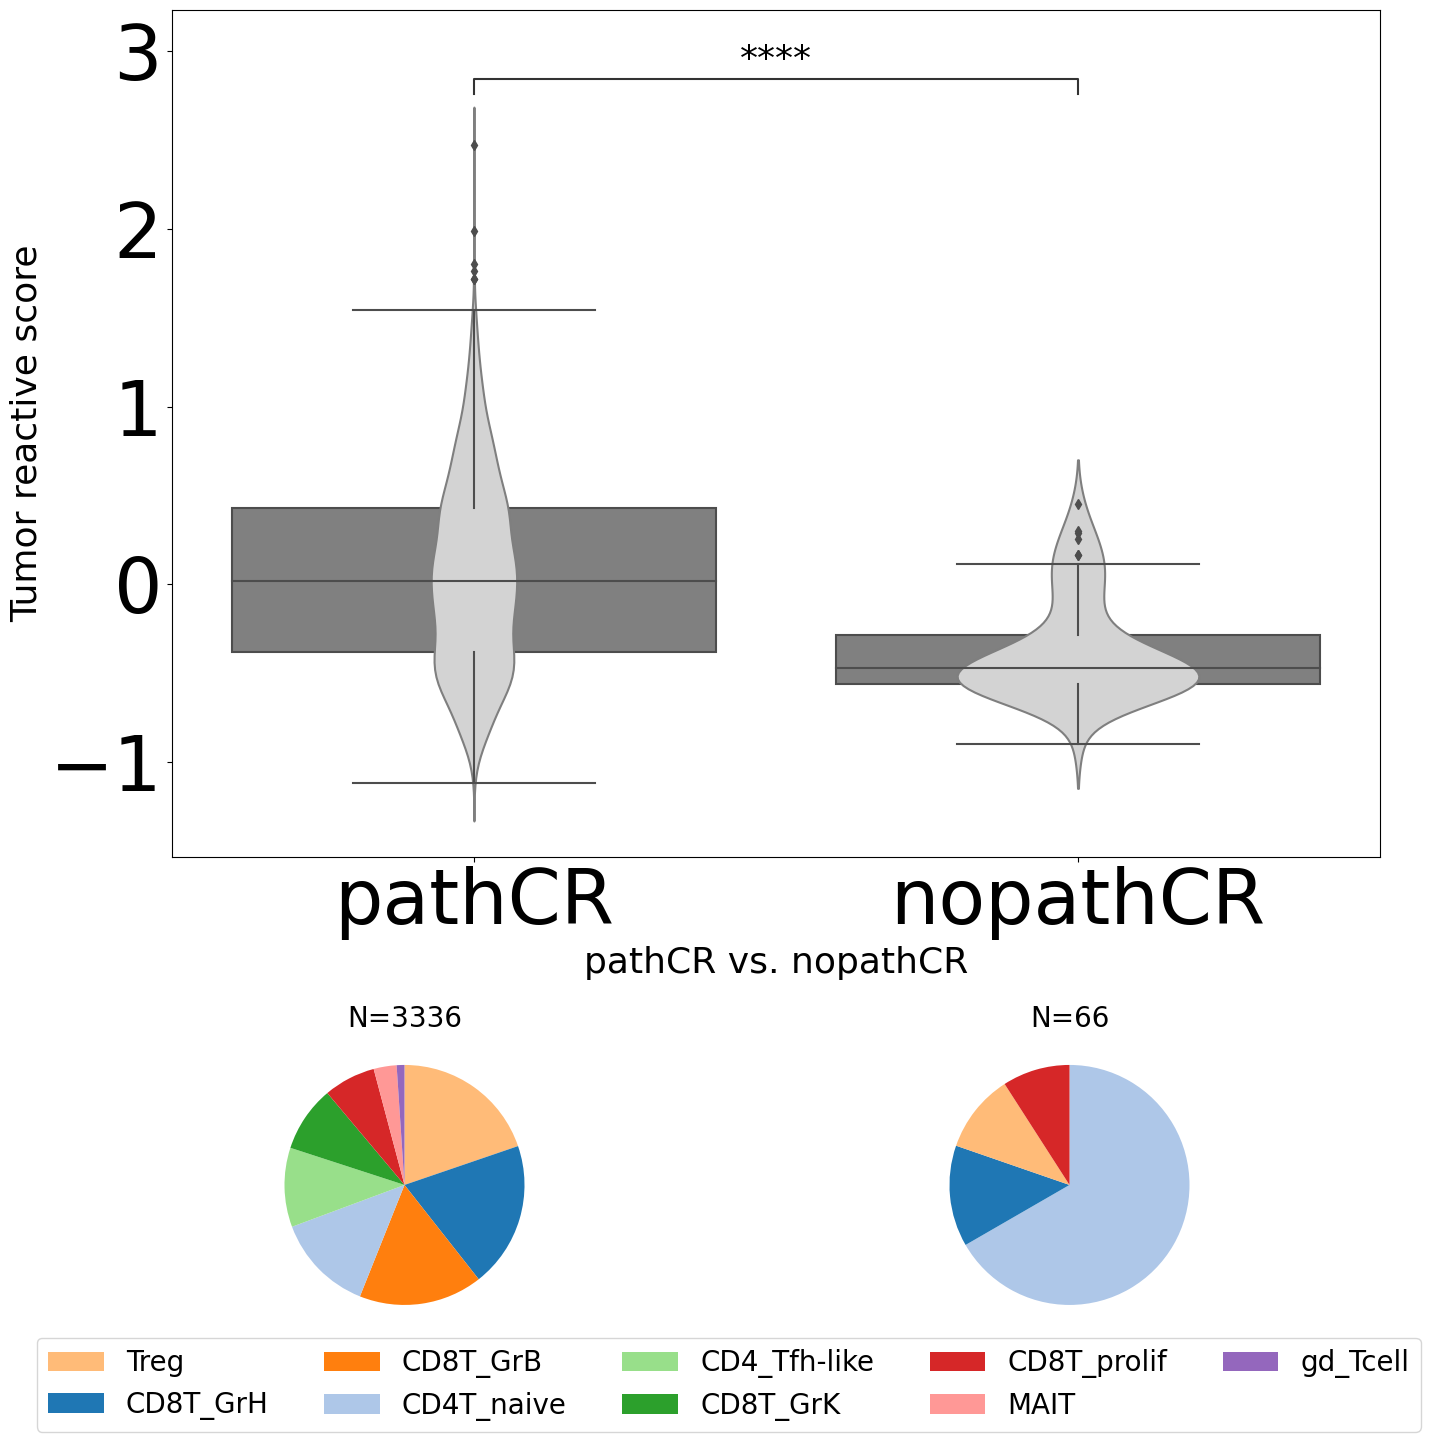

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,pathCR,nopathCR,3277,546,-0.055697,-0.095051,1.658828,0.097567,0.097567


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pathCR","nopathCR" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post
dt_TAA_CR_PD_posttreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_posttreatment["response"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_posttreatment["response"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pathCR","nopathCR")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pathCR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="tumor_reactive",
    order=present_groups,
    # palette=palette,
    color= "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="tumor_reactive",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="tumor_reactive",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for post-treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("pathCR vs. nopathCR", fontsize=26)
ax_box.set_ylabel("Tumor reactive score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_posttreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_posttreatment["response"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_posttreatment[dt_TAA_CR_PD_posttreatment["response"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["response"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["response"] == g1, "tumor_reactive"].dropna()
    x2 = df.loc[df["response"] == g2, "tumor_reactive"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD post treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pathCR vs. nopathCR: t-test independent samples, P_val:1.221e-15 t=8.041e+00


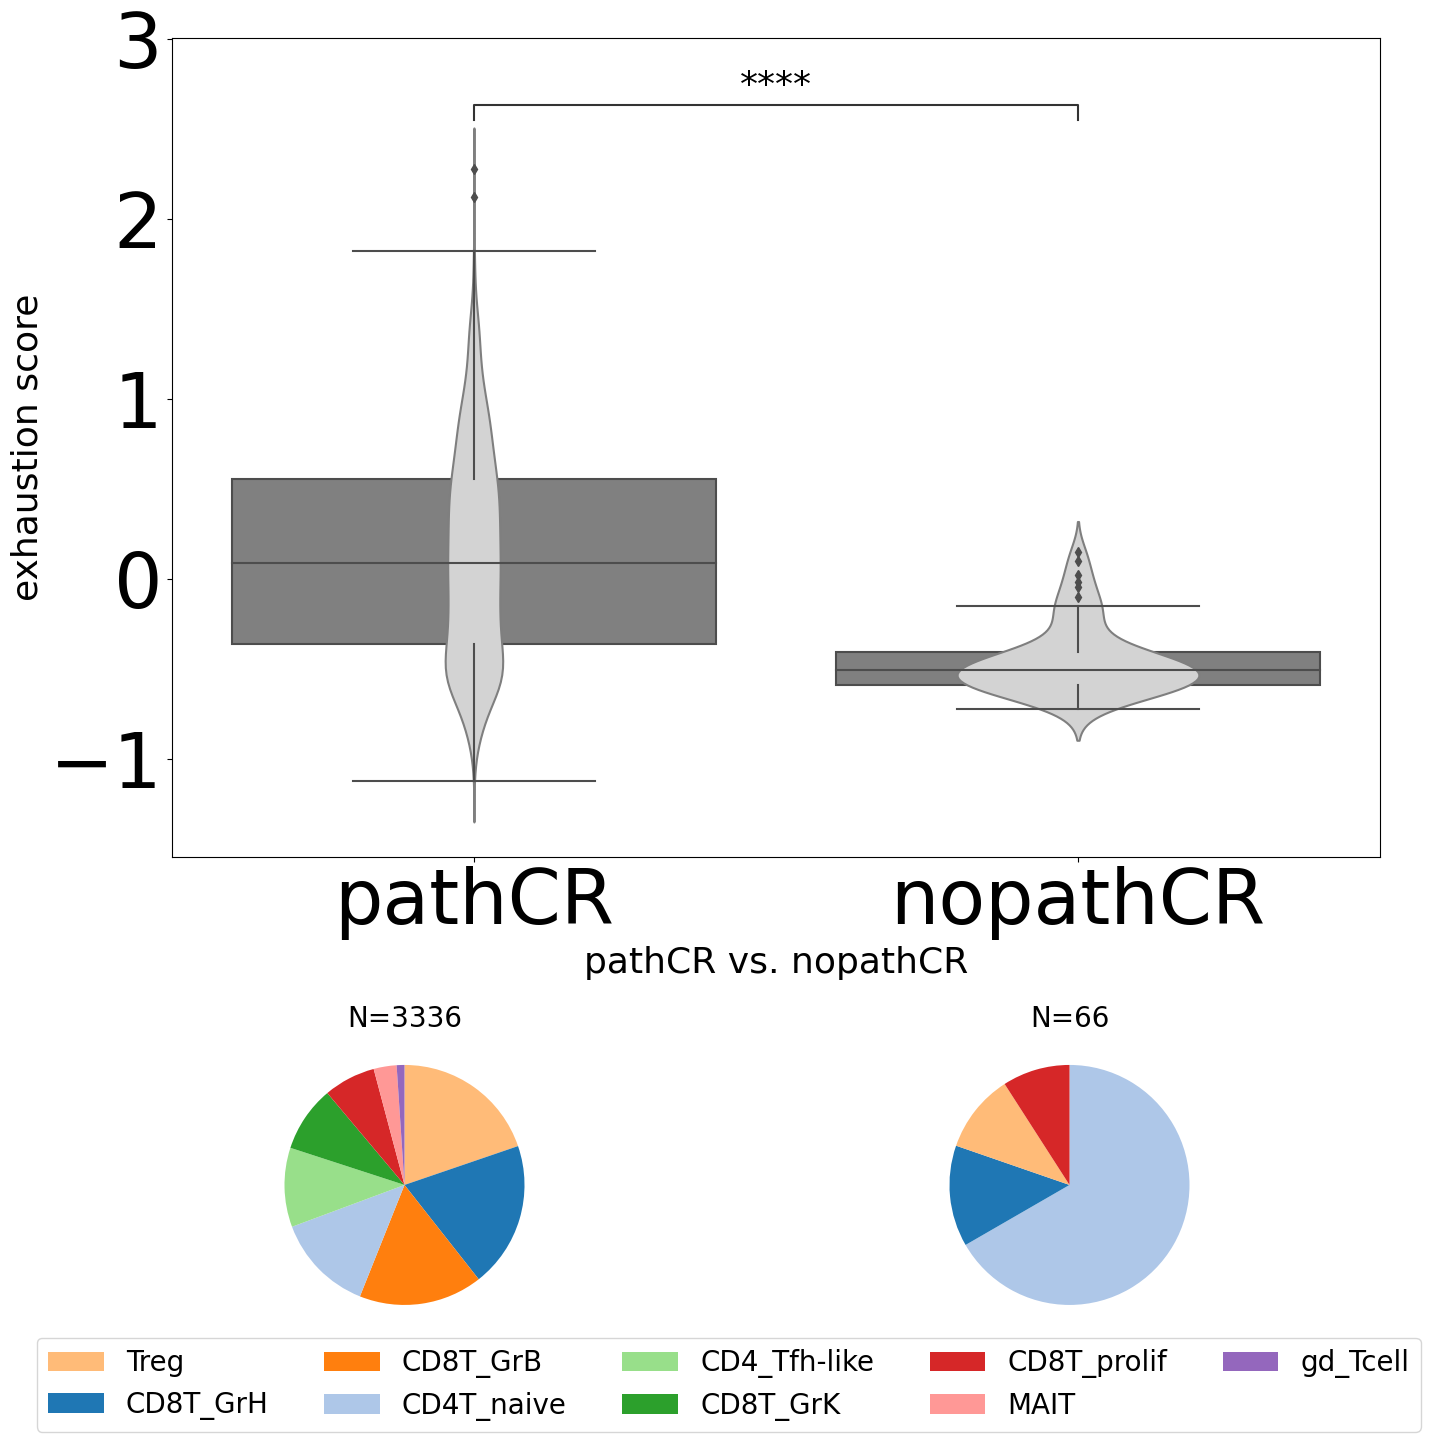

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,pathCR,nopathCR,3277,546,-0.012036,-0.158647,6.089701,1.775678e-09,1.775678e-09


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pathCR","nopathCR" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post
dt_TAA_CR_PD_posttreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_posttreatment["response"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_posttreatment["response"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pathCR","nopathCR")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pathCR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="exhaustion",
    order=present_groups,
    # palette=palette,
    color= "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="exhaustion",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="exhaustion",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for post-treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("pathCR vs. nopathCR", fontsize=26)
ax_box.set_ylabel("exhaustion score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_posttreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_posttreatment["response"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_posttreatment[dt_TAA_CR_PD_posttreatment["response"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["response"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["response"] == g1, "exhaustion"].dropna()
    x2 = df.loc[df["response"] == g2, "exhaustion"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD post treatment within predicted TAA.csv")
results_df

/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/homebrew/Caskroom/miniforge/base/envs/bioinformatics/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version o

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pathCR vs. nopathCR: t-test independent samples, P_val:1.349e-07 t=5.283e+00


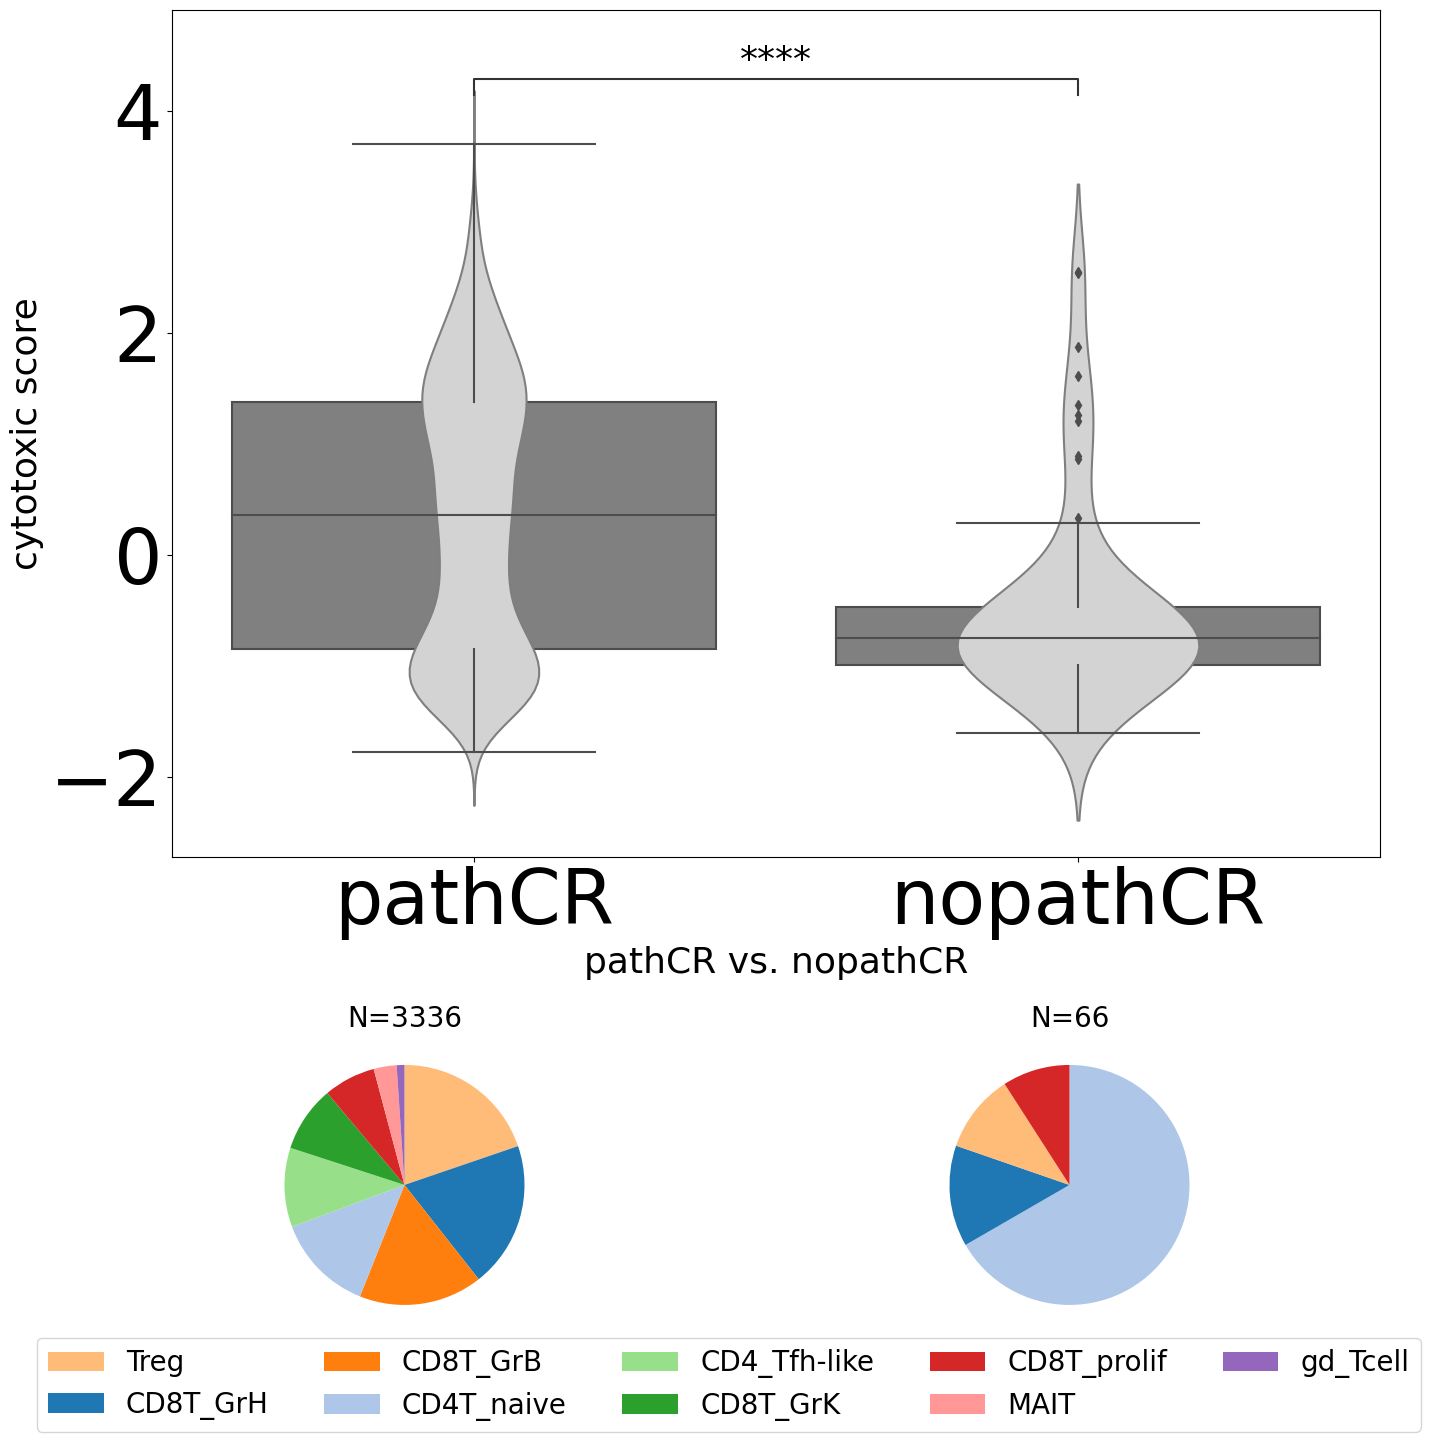

,group1,group2,n1,n2,mean1,mean2,statistic,pvalue,p_adj
0,pathCR,nopathCR,3277,546,0.153447,-0.260531,8.763587,9.912704e-18,9.912704e-18


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

ordered_groups = [ "pathCR","nopathCR" ]
adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post = adata_raw_noHC_no_NA_outcome_high_conf_pathCR_nopathCR_post
dt_TAA_CR_PD_posttreatment = adata_raw_noHC_no_NA_outcome_predicted_TAA_CR_PD_post.obs.copy()

present_groups = [
    g for g in ordered_groups
    if g in dt_TAA_CR_PD_posttreatment["response"].unique()
]

# build pairs automatically from the present leiden groups
leiden_groups = sorted(dt_TAA_CR_PD_posttreatment["response"].astype(str).unique(), reverse=True)
pair_compaire = [
    ("pathCR","nopathCR")
]
# pair_compaire = leiden_groups

palette = {g: "red" if "pathCR" in g else "grey" for g in present_groups}


fig, ax_box = plt.subplots(figsize=(14, 10))

sns.boxplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="cytotoxic",
    order=present_groups,
    # palette=palette,
    color= "grey",
    ax=ax_box
)

sns.violinplot(
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="cytotoxic",
    width=0.4,
    inner=None,
    order=present_groups,
    color="lightgray",
    alpha=0.8,
    ax=ax_box
)

annotator = Annotator(
    ax_box,
    data=dt_TAA_CR_PD_posttreatment,
    x="response",
    y="cytotoxic",
    order=present_groups,
    pairs=pair_compaire
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", fontsize=26, hide_non_significant=True)
annotator.apply_and_annotate()

# ax_box.set_title("Score Comparison CR vs. PD for post-treatment", fontsize=26)
ax_box.tick_params(axis="x",  labelsize=55)
ax_box.tick_params(axis="y",  labelsize=55)
ax_box.set_xlabel("pathCR vs. nopathCR", fontsize=26)
ax_box.set_ylabel("cytotoxic score", fontsize=26)

# Get axis position in figure coordinates
ax_pos = ax_box.get_position()

# Get x positions of categories
all_cell_types = dt_TAA_CR_PD_posttreatment["final_cell_type"].unique()
palette = sns.color_palette("tab20", len(all_cell_types))
color_map = dict(zip(all_cell_types, palette))
xticks = ax_box.get_xticks()

all_labels = None
all_handles = None
groups = dt_TAA_CR_PD_posttreatment["response"].unique()
for i, (x, grp) in enumerate(zip(xticks, groups)):
    sub = dt_TAA_CR_PD_posttreatment[dt_TAA_CR_PD_posttreatment["response"] == grp]
    counts = sub["final_cell_type"].value_counts()
    colors = [color_map[c] for c in counts.index]
    x_fig = ax_pos.x0 -0.22 + (x - ax_box.get_xlim()[0]) / (ax_box.get_xlim()[1] - ax_box.get_xlim()[0]) * 0.95
    y_fig = ax_pos.y0 - 0.45

    ax_pie = fig.add_axes([x_fig, y_fig, 0.3, 0.3])

    wedges, texts= ax_pie.pie(
        counts.values,
        labels=None,          # no labels on the pies
        autopct=None,
        startangle=90,
        colors=colors,
        counterclock=False,
    )

    ax_pie.set_aspect("equal")
    total = counts.sum()
    ax_pie.set_title(f"N={total}", fontsize=20)
    # save legend items only once
    if all_labels is None:
        all_labels = counts.index.tolist()
        all_handles = wedges
fig.legend(
    all_handles,
    all_labels,
    loc="center left",
    bbox_to_anchor=(0.02, y_fig - 0.05),
    # title="Cell type",
    fontsize=20,
    ncol=5
)


plt.tight_layout()
plt.show()


df = dt_TAA_CR_PD_pretreatment

groups = df["response"].dropna().unique()
pairs = list(itertools.combinations(groups, 2))

results = []

for g1, g2 in pairs:
    x1 = df.loc[df["response"] == g1, "cytotoxic"].dropna()
    x2 = df.loc[df["response"] == g2, "cytotoxic"].dropna()

    stat, pval = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test

    results.append({
        "group1": g1,
        "group2": g2,
        "n1": len(x1),
        "n2": len(x2),
        "mean1": x1.mean(),
        "mean2": x2.mean(),
        "statistic": stat,
        "pvalue": pval,
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
results_df["p_adj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

# results_df.to_csv("tumor_reactive CR vs PD post treatment within predicted TAA.csv")
results_df

In [613]:
adata_HVG_no_HC_CR_PD = sc.read_h5ad("adata_HVG_no_HC_CR_PD.h5ad")

In [614]:
adata_HVG_no_HC_CR_PD.obs['leiden'].value_counts()

leiden
0    2823
1    1788
2    1587
4    1381
3    1032
5     828
7     573
6     468
8     458
Name: count, dtype: int64